In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

np.random.seed(1)

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [15]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

ValueError: A colormap named "my_cmap" is already registered.

In [16]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




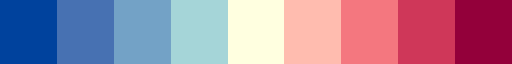

In [17]:
my_cmap



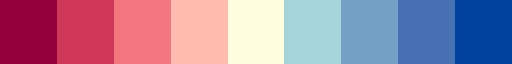

In [18]:
my_cmap_r


In [19]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

In [20]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path="Data/test"):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

In [21]:
session_name="Data/VectorDecomposition"
if not os.path.exists(session_name):

   # Create a new directory because it does not exist
   os.makedirs(session_name)
   print("The new directory is created!")


###################
######################################
#########################################################

N_simul=100
S=12
u_list=np.arange(0,1.2,0.1)
o=0
t=[0,5000]
num_C=2
num_S=12
N=num_C*num_S
threshold=1e-3

###################
######################################
#########################################################
Intention_to_reset=False
if Intention_to_reset or not os.path.isfile(session_name+'/Data_Assymetricity.xlsx'):
    Data_1=np.zeros((len(u_list),N_simul))
    Data_2=np.zeros((len(u_list),N_simul))
    Data_3=np.zeros((len(u_list),N_simul))
    
    for i,u in enumerate(u_list):
        for itt in range(N_simul):
            ###########
            np.random.seed(itt)
            f_interaction=lambda : uniform_distribution(u,o)

            I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

            CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

            y=np.random.rand(N)*0.1
            y1=run_lotka_volterra(y, t, CommunitiesLibrary[0,:], I, g, k)
            y2=run_lotka_volterra(y, t, CommunitiesLibrary[1,:], I, g, k)

            y1[y1<threshold]=0
            y2[y2<threshold]=0
            y3=np.array(y1+y2)
            survived=y3>threshold
            y3=run_lotka_volterra(y3, t, survived, I, g, k)
            y3[y3<threshold]=0
            Similarity_to1 =(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))

            Assimilarity_BC=abs(2* Similarity_to1-1)
            a,b,c=metric_VectorDecomposition_onlyPositive(y1,y2,y3)
            Data_1[i,itt]=a
            Data_2[i,itt]=b
            Data_3[i,itt]=c

            #########

            
    df1=pd.DataFrame(Data_1)
    df2=pd.DataFrame(Data_2)
    df3=pd.DataFrame(Data_3)

    with pd.ExcelWriter(session_name+'/Data_Assymetricity.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
        df2.to_excel(writer,sheet_name='Sheet2')
        df3.to_excel(writer,sheet_name='Sheet3')

In [22]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet1')
df = df.values[0:,1:]
df1=df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet2')
df = df.values[0:,1:]
df2 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet3')
df = df.values[0:,1:]
df3 = df

In [23]:
def calculate_assymetricity(u,v,k):
    x=np.sqrt(np.array(u)**2+np.array(v)**2)
    y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)  
    return x,y

def characterize_case(x,y):
    if (x**2>0.5)*(y>0.5):
        return 0
    if (x**2>0.5)*(y<0.5):
        return 1
    if (x**2<0.5):
        return 2

In [24]:
colors = ['#003f5c', '#ffa600', '#bc5090']


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_54477/3697704590.py:3: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_54477/3697704590.py:3: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


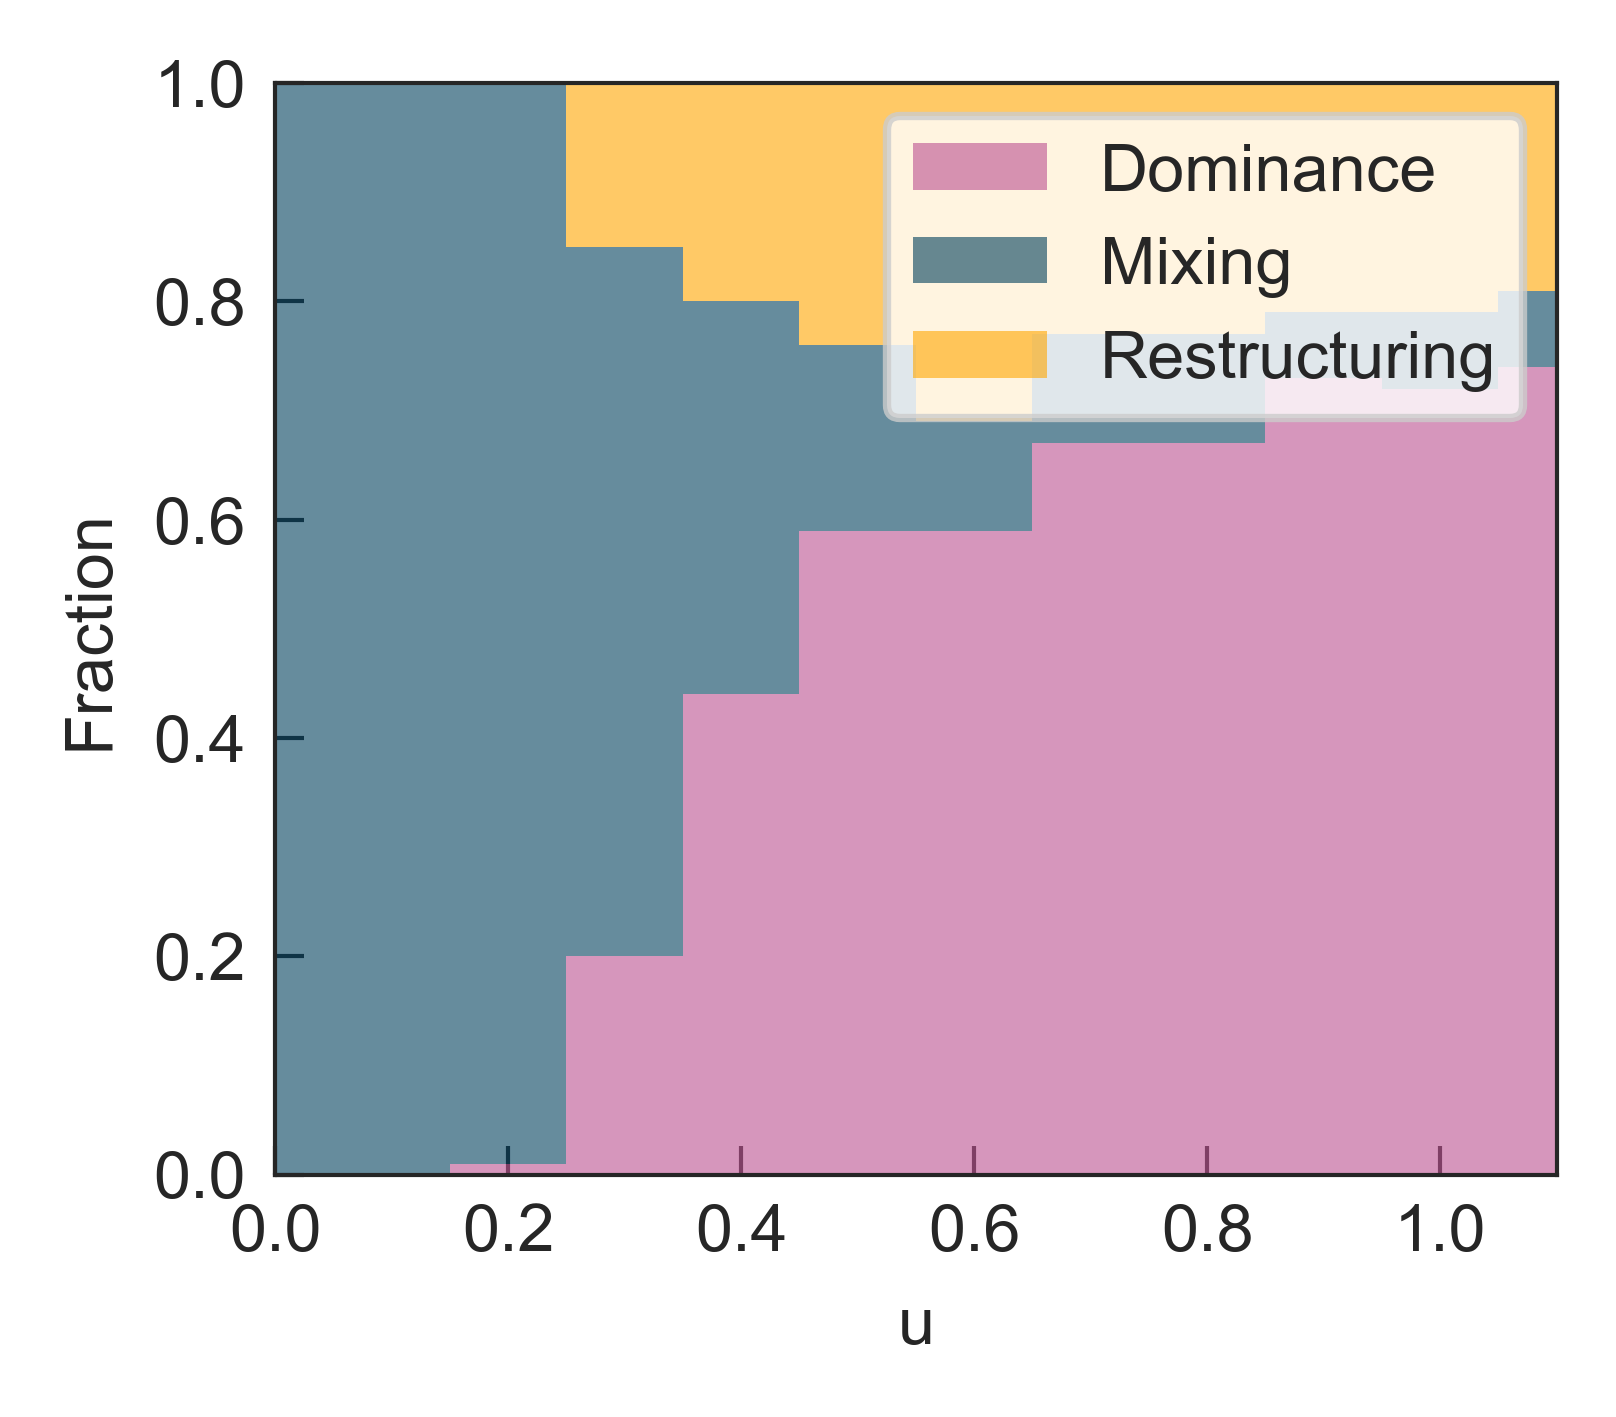

In [25]:
# Sample data: values of x and corresponding fractions for three classes

colors=["grey", my_cmap(0), "blue"]
colors = ['#bc5090', '#003f5c','#ffa600' ]

class1_fractions=np.zeros(size(df1,0))
class2_fractions=np.zeros(size(df1,0))
class3_fractions=np.zeros(size(df1,0))

class1=np.array([])
class2=np.array([])
class3=np.array([])
for i in range(size(df1,0)):
    class1_count=0
    class2_count=0
    class3_count=0
    for j in range(size(df1,1)):
        x,y=calculate_assymetricity(df1[i,j],df2[i,j],df3[i,j])
        ii=characterize_case(x,y)
        if ii==0:
            class1_count+=1
        if ii==1:
            class2_count+=1
        if ii==2:
            class3_count+=1
    total_count=class1_count+class2_count+class3_count
    class1_fractions[i]=class1_count/total_count
    class2_fractions[i]=class2_count/total_count
    class3_fractions[i]=class3_count/total_count

f, ax = plt.subplots(1, figsize=(70*mm,60*mm),facecolor='w', edgecolor='k')

    
# Create a stacked, filled bar plot for each x value
width = 0.5  # Width of the bars

# Create an array of x values for each class to form a connected line
x_values_array = np.array(u_list)

# Plot each class's fractions as stacked, filled bars
plt.fill_between(x_values_array, 0, class1_fractions, step='mid', label='Dominance', color=colors[0], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions, class1_fractions + class2_fractions, step='mid', label='Mixing', color=colors[1], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions + class2_fractions, class3_fractions + class2_fractions + class1_fractions, color=colors[2], alpha=0.6, step='mid', label='Restructuring', edgecolor='none')

# Add labels and a legend
plt.xlabel('u')
plt.ylabel('Fraction')
plt.xlim([0,1.1])
plt.ylim([0,1])
#plt.title('Stacked and Filled Bar Plot of Three Classes for Each X Value')
plt.legend()

# Display the plot
f.savefig(f'Figure/Fig_classes_map.svg',bbox_inches='tight')
plt.show()


In [26]:
from scipy.stats import gaussian_kde


def PolarizedPlot(data1,data2):
        colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        ax.scatter(data1,data2, s=25,color=colors[c_i], marker='.', alpha=0.7,linewidths=0)
        ax.scatter(data2,data1, s=25,color='grey', marker='.', alpha=0.2,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        #plt.xlabel('to C1')
        #plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        return f
        
def thetaplot(data1, data2, color='blue', smoothing=0.1):
    """
    Plots a smoothed histogram of θ = arctan(data1/data2), limited to the range -π/4 to π/4, with shading under the smoothed line.

    Parameters:
        data1, data2: Lists or arrays of data points to compute θ
        color: Color of the histogram bars and KDE curve (default is blue)
        smoothing: Bandwidth for the KDE smoothing (default is 0.2)

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    
    # Calculate theta using arctan2 and restrict to [-π/4, π/4]
    theta = np.arctan2(data1, data2) - np.pi/4
    theta = np.append(theta,-theta)    #theta = theta[(theta >= -np.pi/4) & (theta <= np.pi/4)]
    
    # Create figure
    f, ax = plt.subplots(figsize=(60*mm,30*mm))
    
    # KDE for smoothing
    kde = gaussian_kde(theta, bw_method=smoothing)
    theta_vals = np.linspace(-np.pi/4, np.pi/4, 500)
    kde_vals = kde(theta_vals)
    
    # Plot the KDE line
    #ax.plot(theta_vals, kde_vals, color=colors[c_i], linewidth=1, label='Smoothed Density')
    ax.hist(theta, bins=20, range=(-np.pi/4, np.pi/4), color=colors[c_i], alpha=0.5, edgecolor='white', density=True)
    # Shade area under the KDE line
    ax.fill_between(theta_vals, kde_vals, color=colors[c_i], alpha=0.3)
    
    # Set labels and title
    #ax.set_xlabel(r'$\theta = \arctan\left(\frac{\mathrm{data1}}{\mathrm{data2}}\right)$')
    #ax.set_ylabel('Count')
    #ax.set_title('Histogram of θ with Smoothing and Shaded Area')
    
    # Set x-axis limits and ticks
    ax.set_xlim(-np.pi/4, np.pi/4)
    ax.set_ylim(0, 4.5)

    ax.set_xticks([-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4])
    ax.set_xticklabels([r'$-\frac{\pi}{4}$', r'$-\frac{\pi}{8}$', '0', r'$\frac{\pi}{8}$', r'$\frac{\pi}{4}$'])
    
    plt.tight_layout()
    
    return f

def rplot(data1, data2, color='blue', smoothing=0.1):
    """
    Plots a smoothed histogram of r = sqrt(data1**2 + data2**2) with shading under the smoothed line.

    Parameters:
        data1, data2: Lists or arrays of data points to compute r
        color: Color of the histogram bars and KDE curve (default is blue)
        smoothing: Bandwidth for the KDE smoothing (default is 0.1)

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    
    # Calculate r as the Euclidean distance
    r = np.sqrt(np.array(data1)**2 + np.array(data2)**2)
    
    # Create figure
    f, ax = plt.subplots(figsize=(60*mm,30*mm))
    
    # KDE for smoothing
    kde = gaussian_kde(r, bw_method=smoothing)
    r_vals = np.linspace(r.min(), r.max(), 500)
    kde_vals = kde(r_vals)
    
    # Plot the KDE line
    #ax.plot(r_vals, kde_vals, color=colors[c_i], linewidth=1.5, label='Smoothed Density')
    
    # Plot histogram with white edges on bars
    ax.hist(r, bins=20, color=colors[c_i], alpha=0.5, edgecolor='white', density=True)
    
    # Shade area under the KDE line
    ax.fill_between(r_vals, kde_vals, color=colors[c_i], alpha=0.3)
    
    # Set labels and title
    #ax.set_xlabel(r'$r = \sqrt{\mathrm{data1}^2 + \mathrm{data2}^2}$')
    #ax.set_ylabel('Density')
    #ax.set_title('Histogram of r with Smoothing and Shaded Area')
    
    # Set x-axis limits based on range of r
    ax.set_xlim(0, 1)
    
    plt.tight_layout()
    
    return f



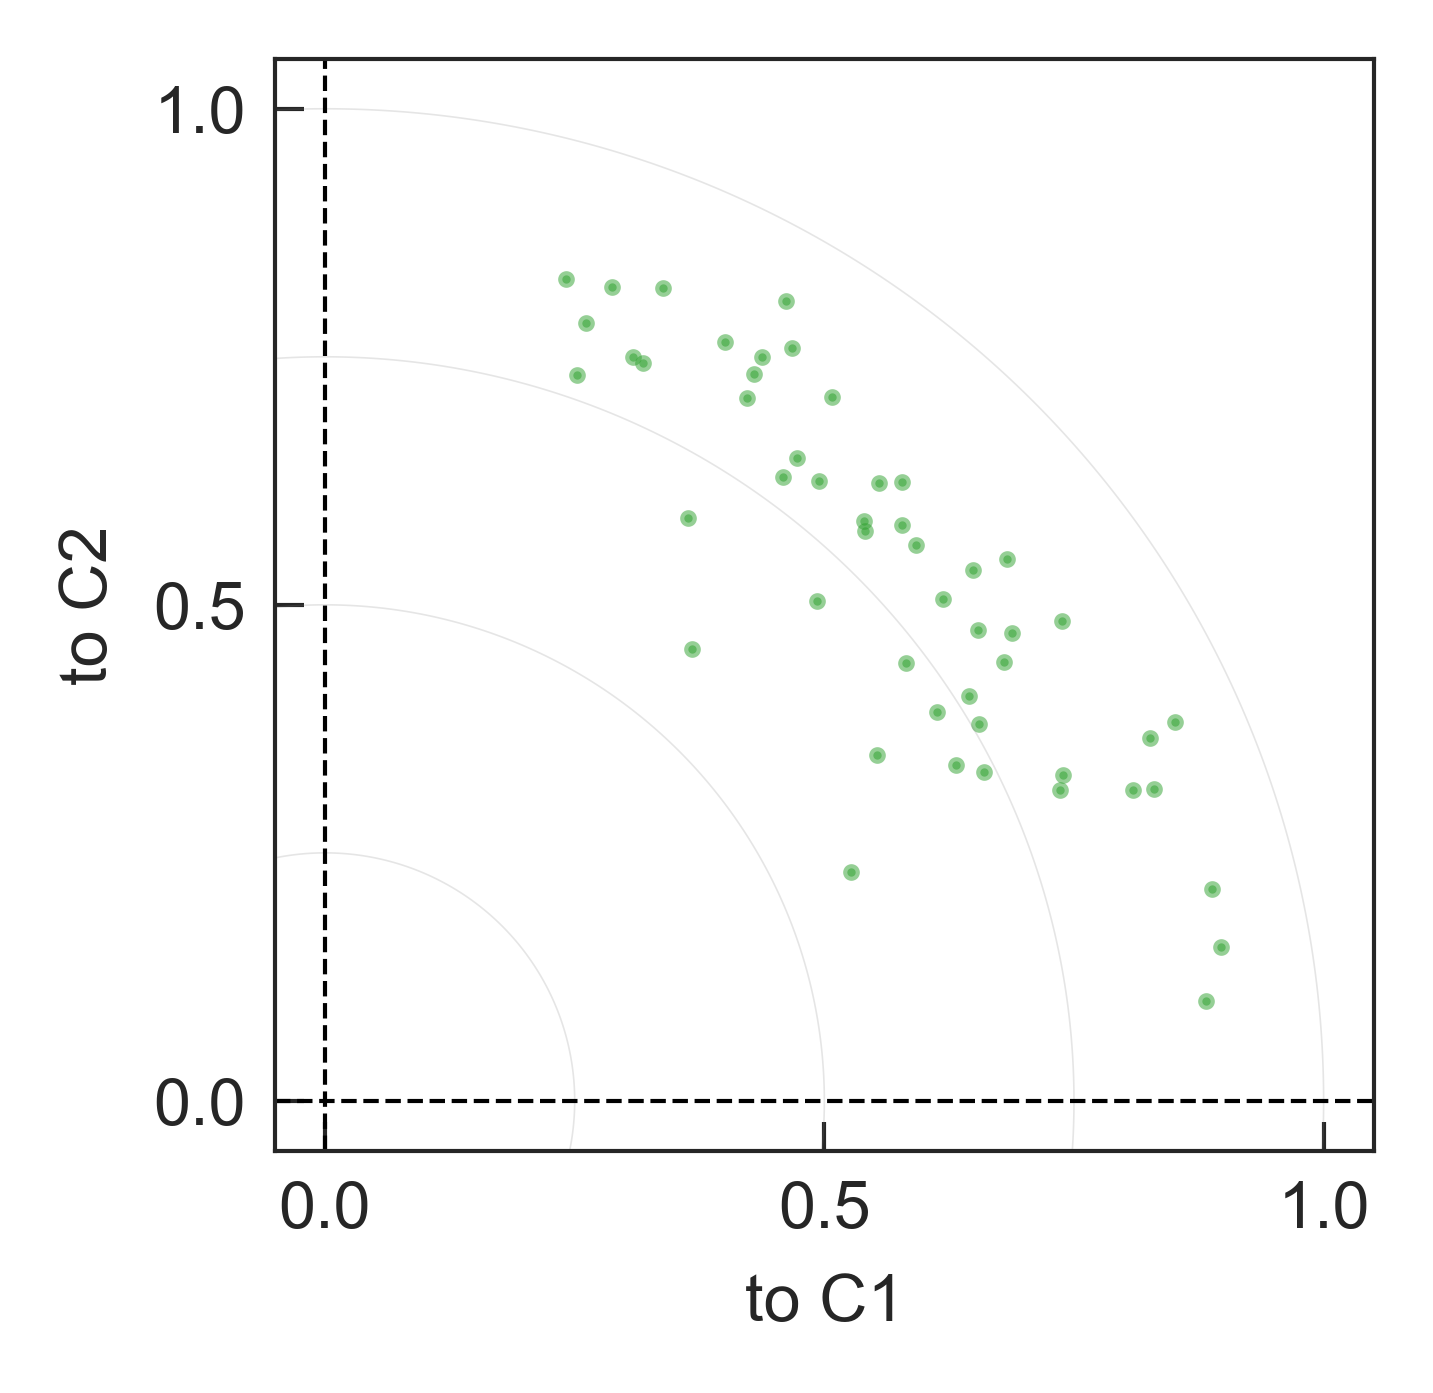

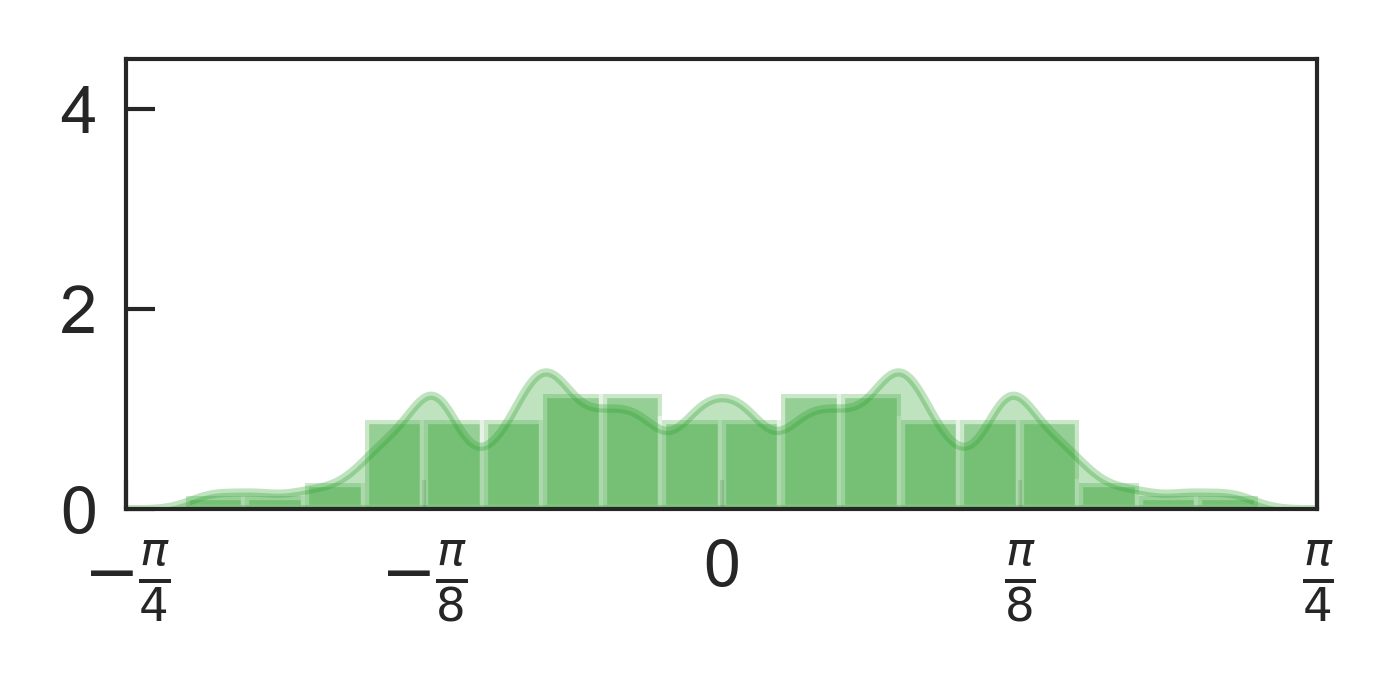

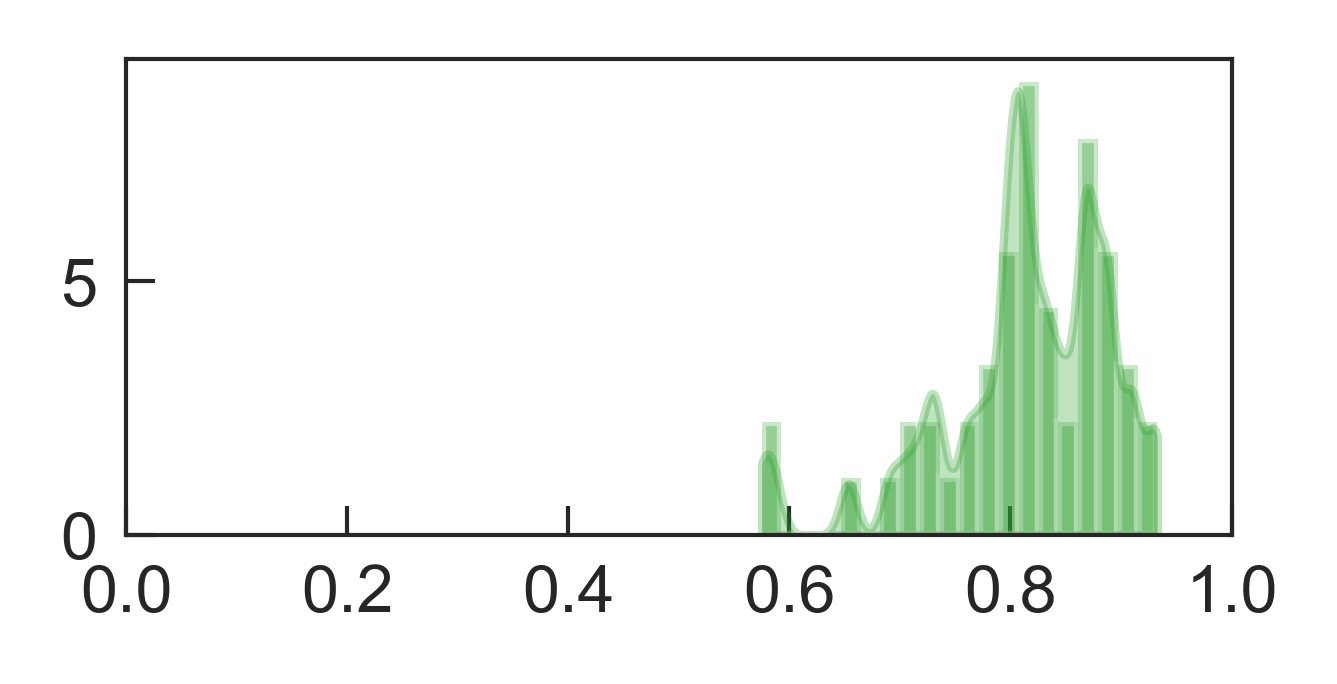

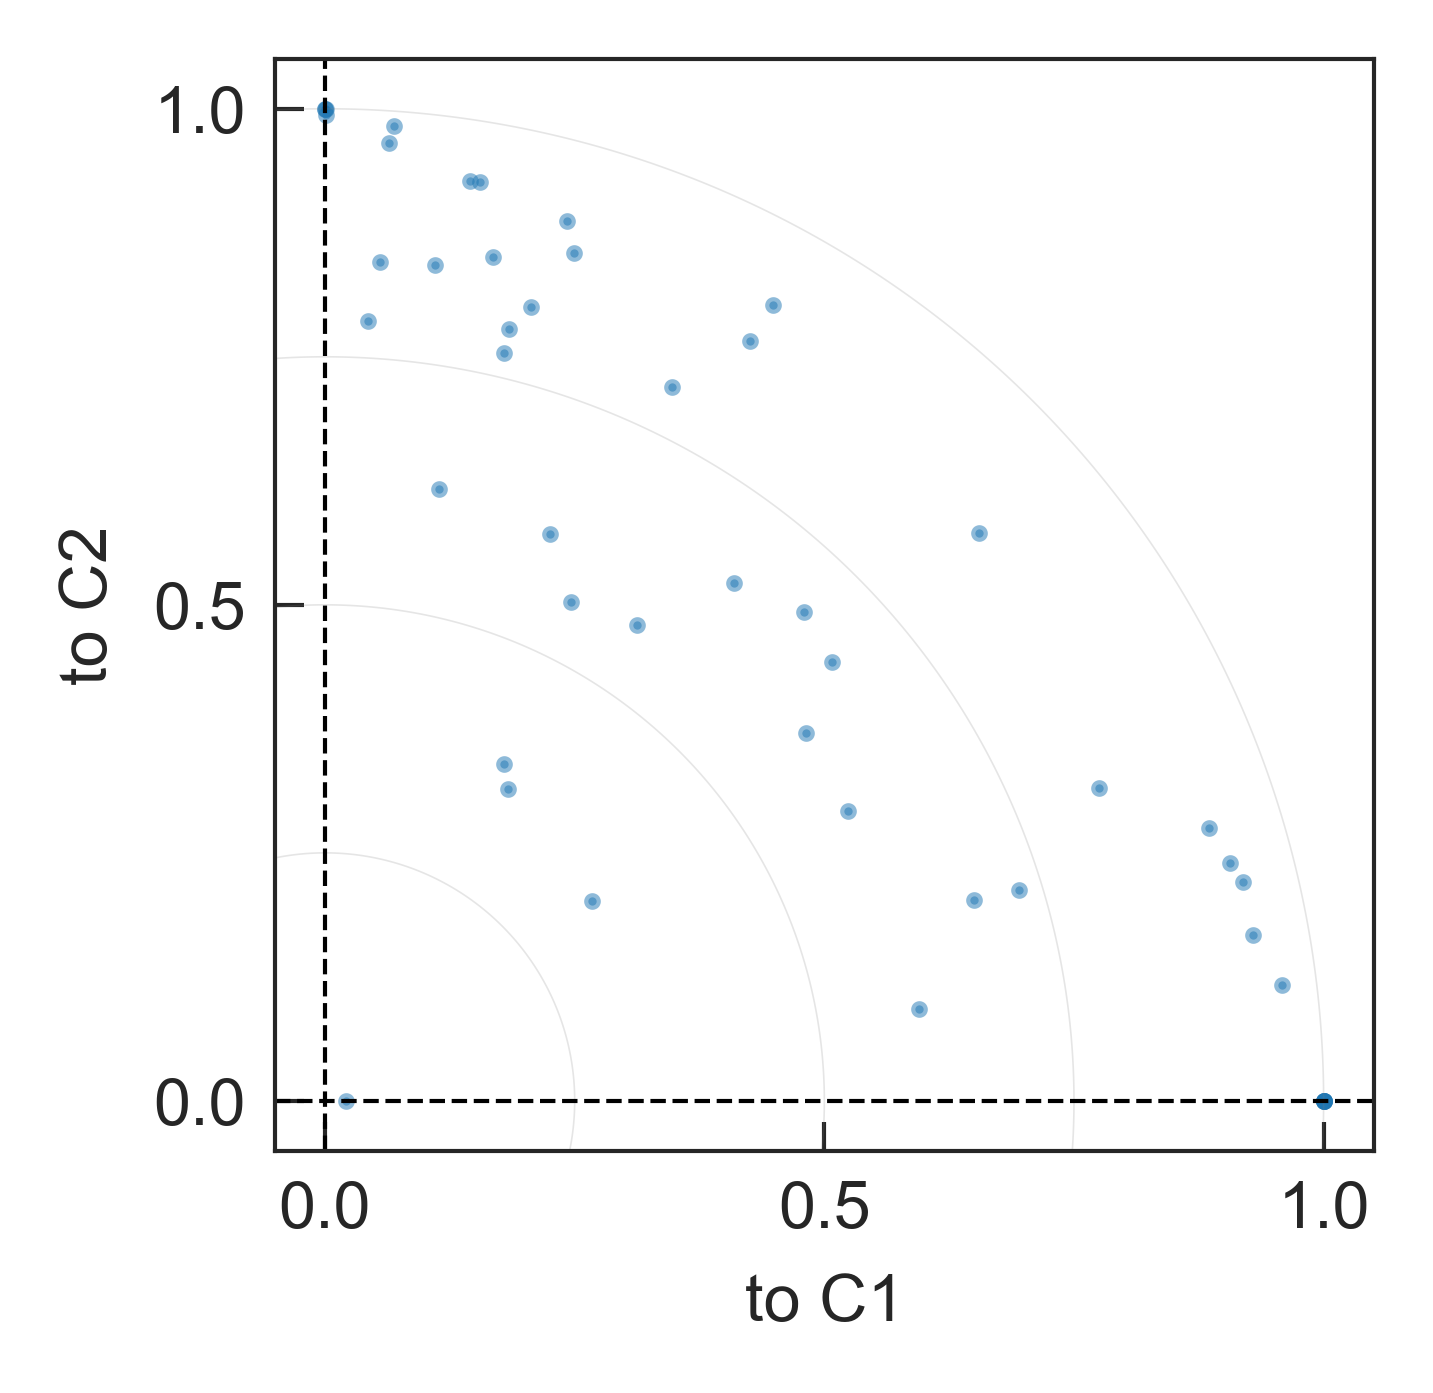

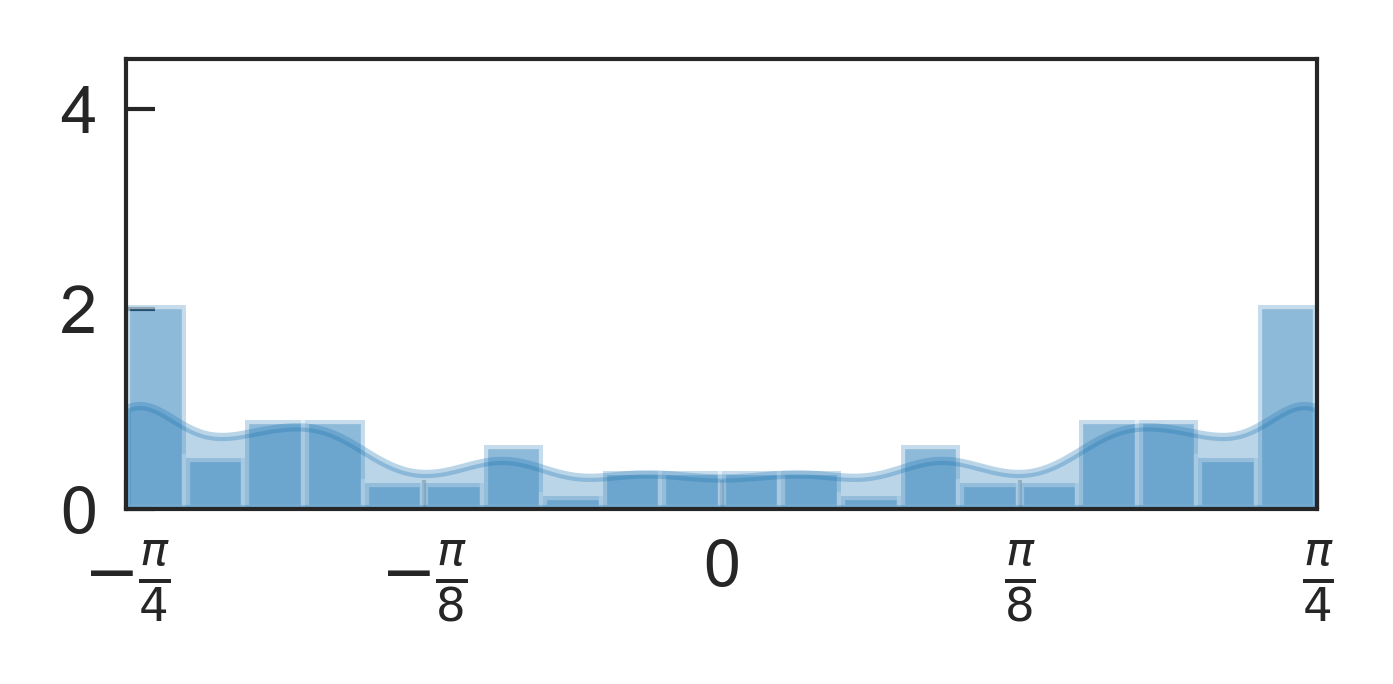

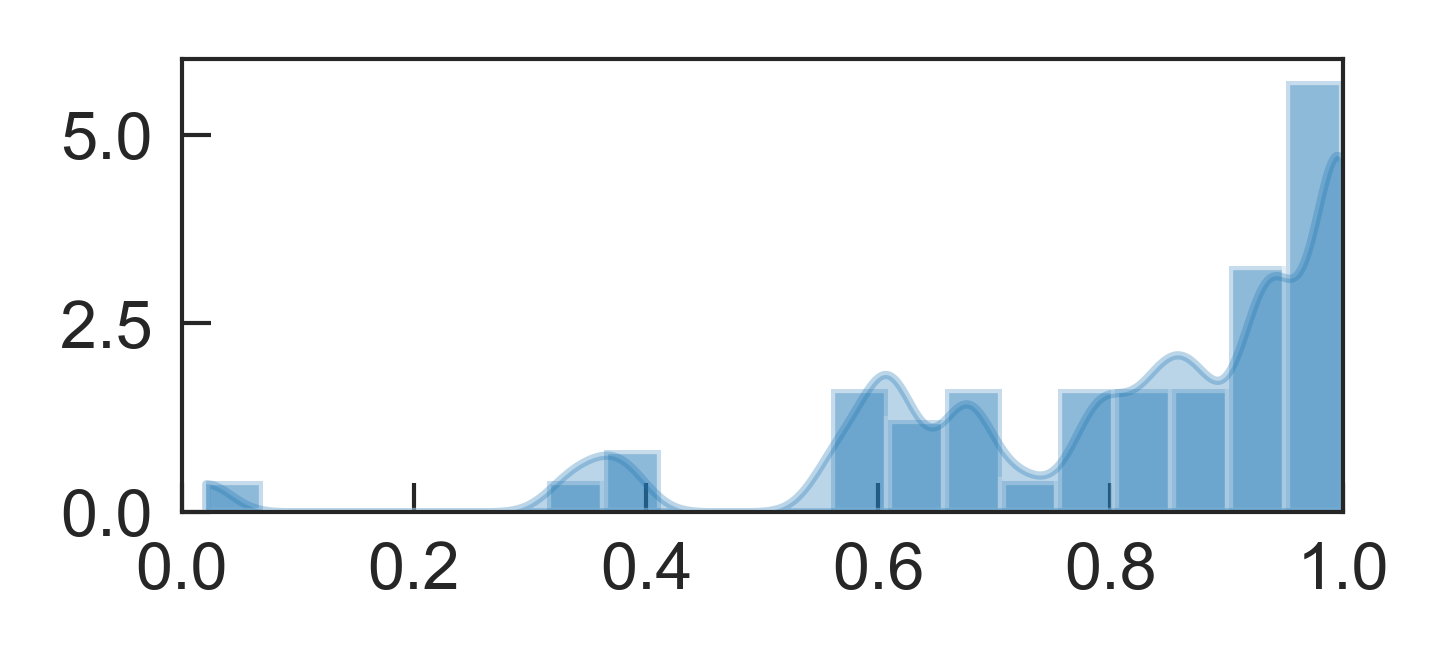

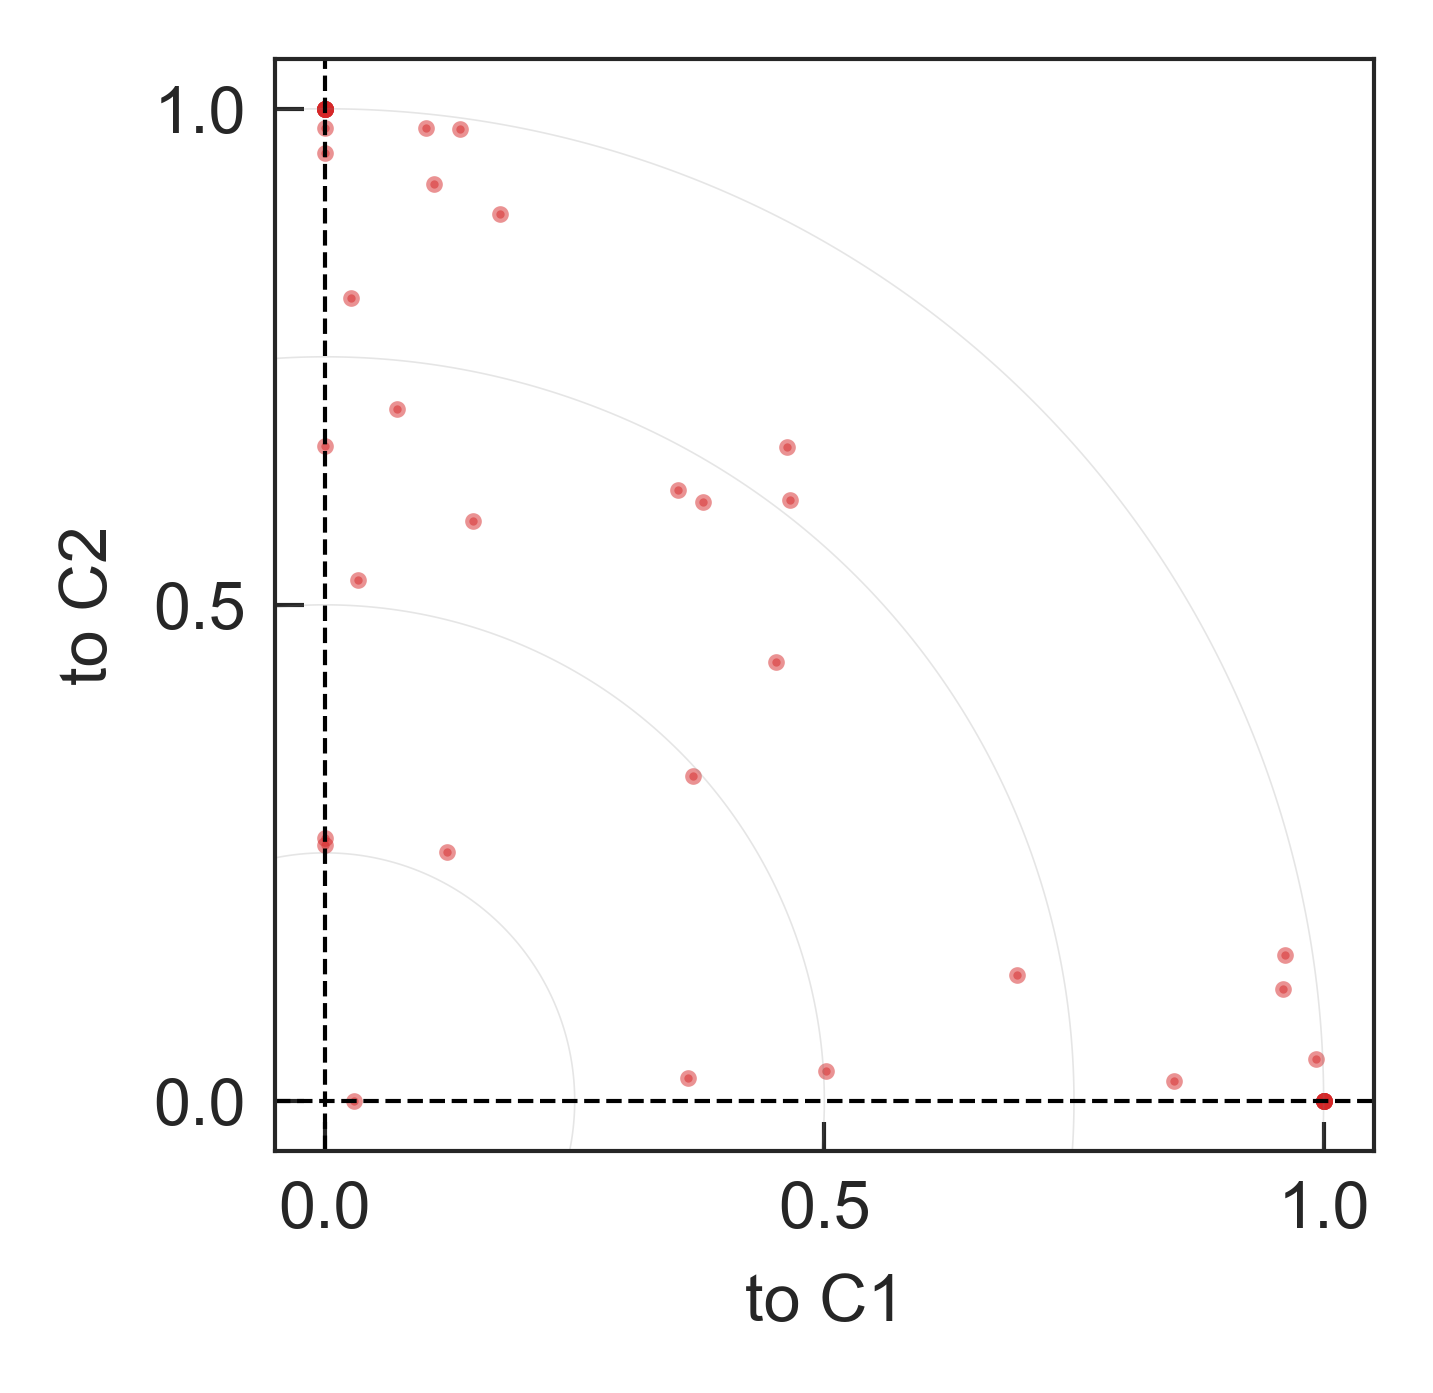

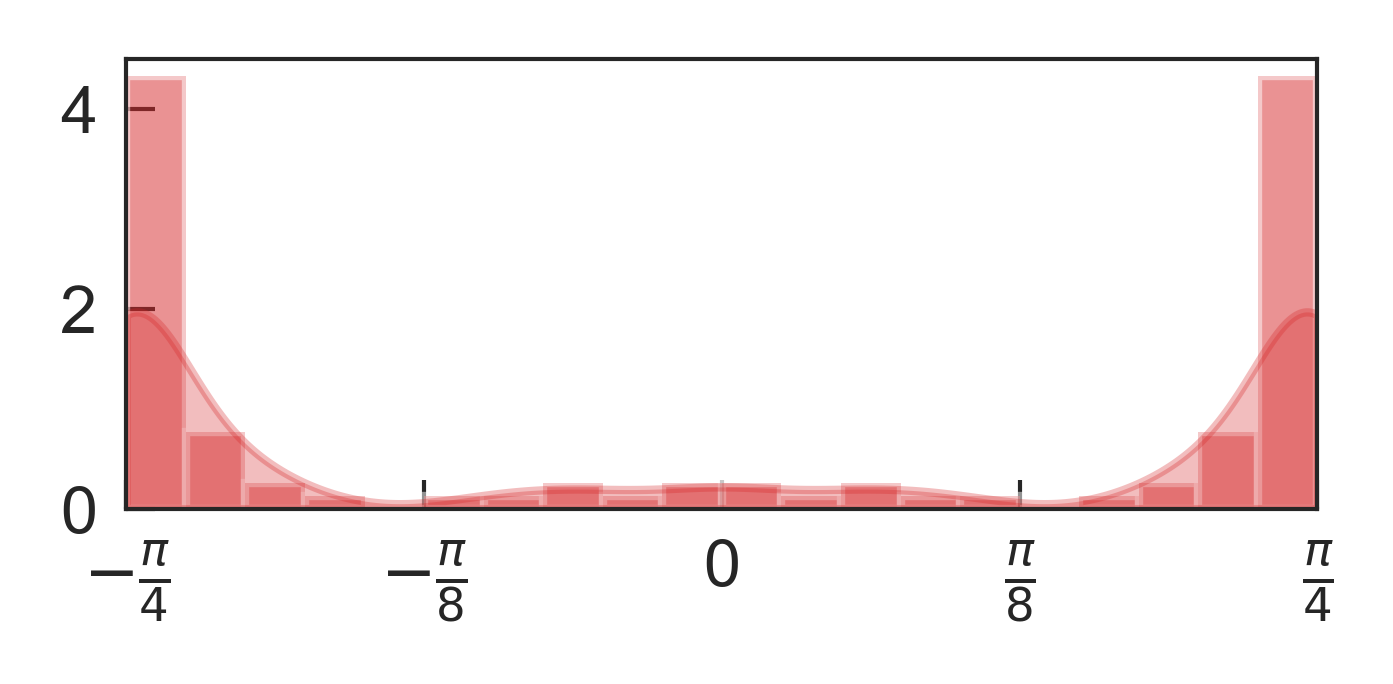

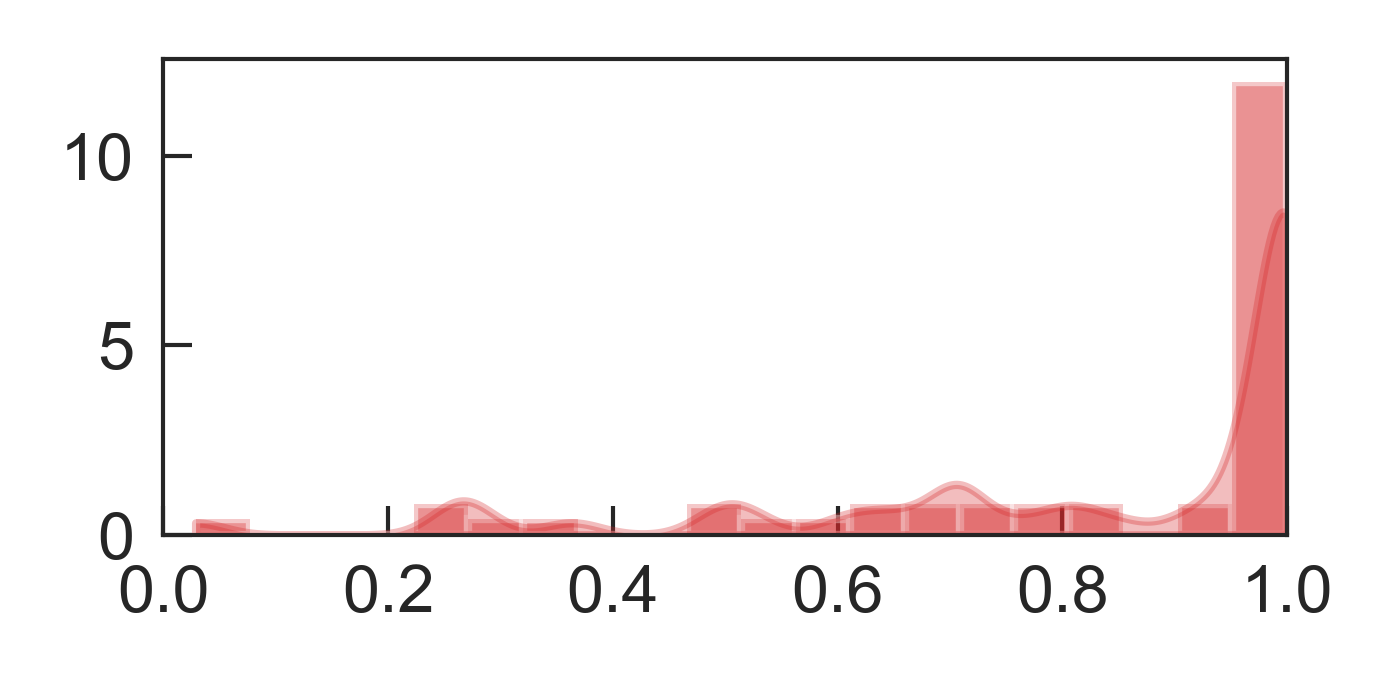

In [27]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(43)
N=50
for c_i,i in enumerate([3, 6, 9]):

    Null_model_rep=5



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        data1=df1[i,:N]
        data2=df2[i,:N]


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        scatter(data1,data2,s=1,color=colors[c_i],alpha=0.5)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.2)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('to C1')
        plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{u_list[i]}_style1.svg',bbox_inches='tight')

    if True:
        fig = thetaplot(data1, data2)
        fig.savefig(f'Figure/Metric_metric3_{u_list[i]}_)theta_style1.svg',bbox_inches='tight')
        fig = rplot(data1, data2)
        fig.savefig(f'Figure/Metric_metric3_{u_list[i]}_r_style1.svg',bbox_inches='tight')





        

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/2359870571.py:68: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/2359870571.py:68: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)


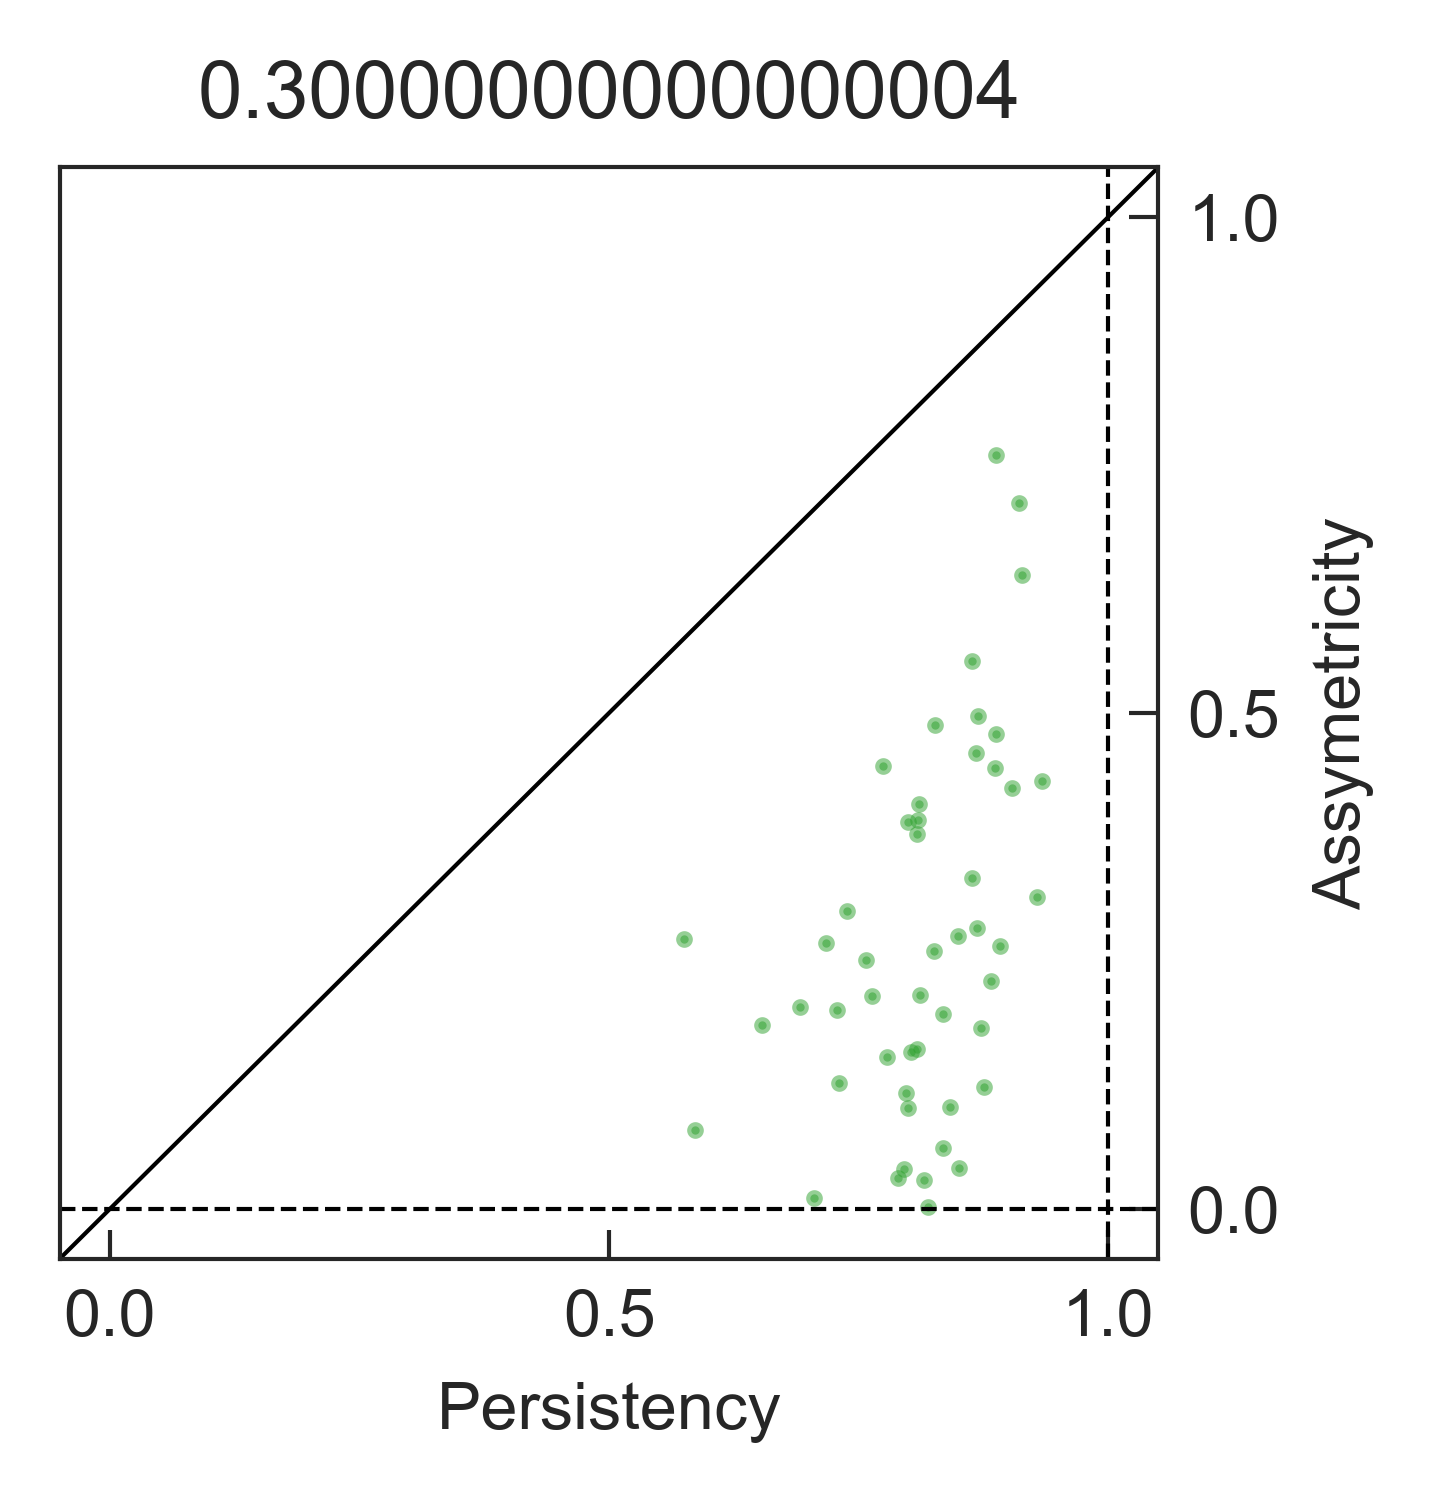

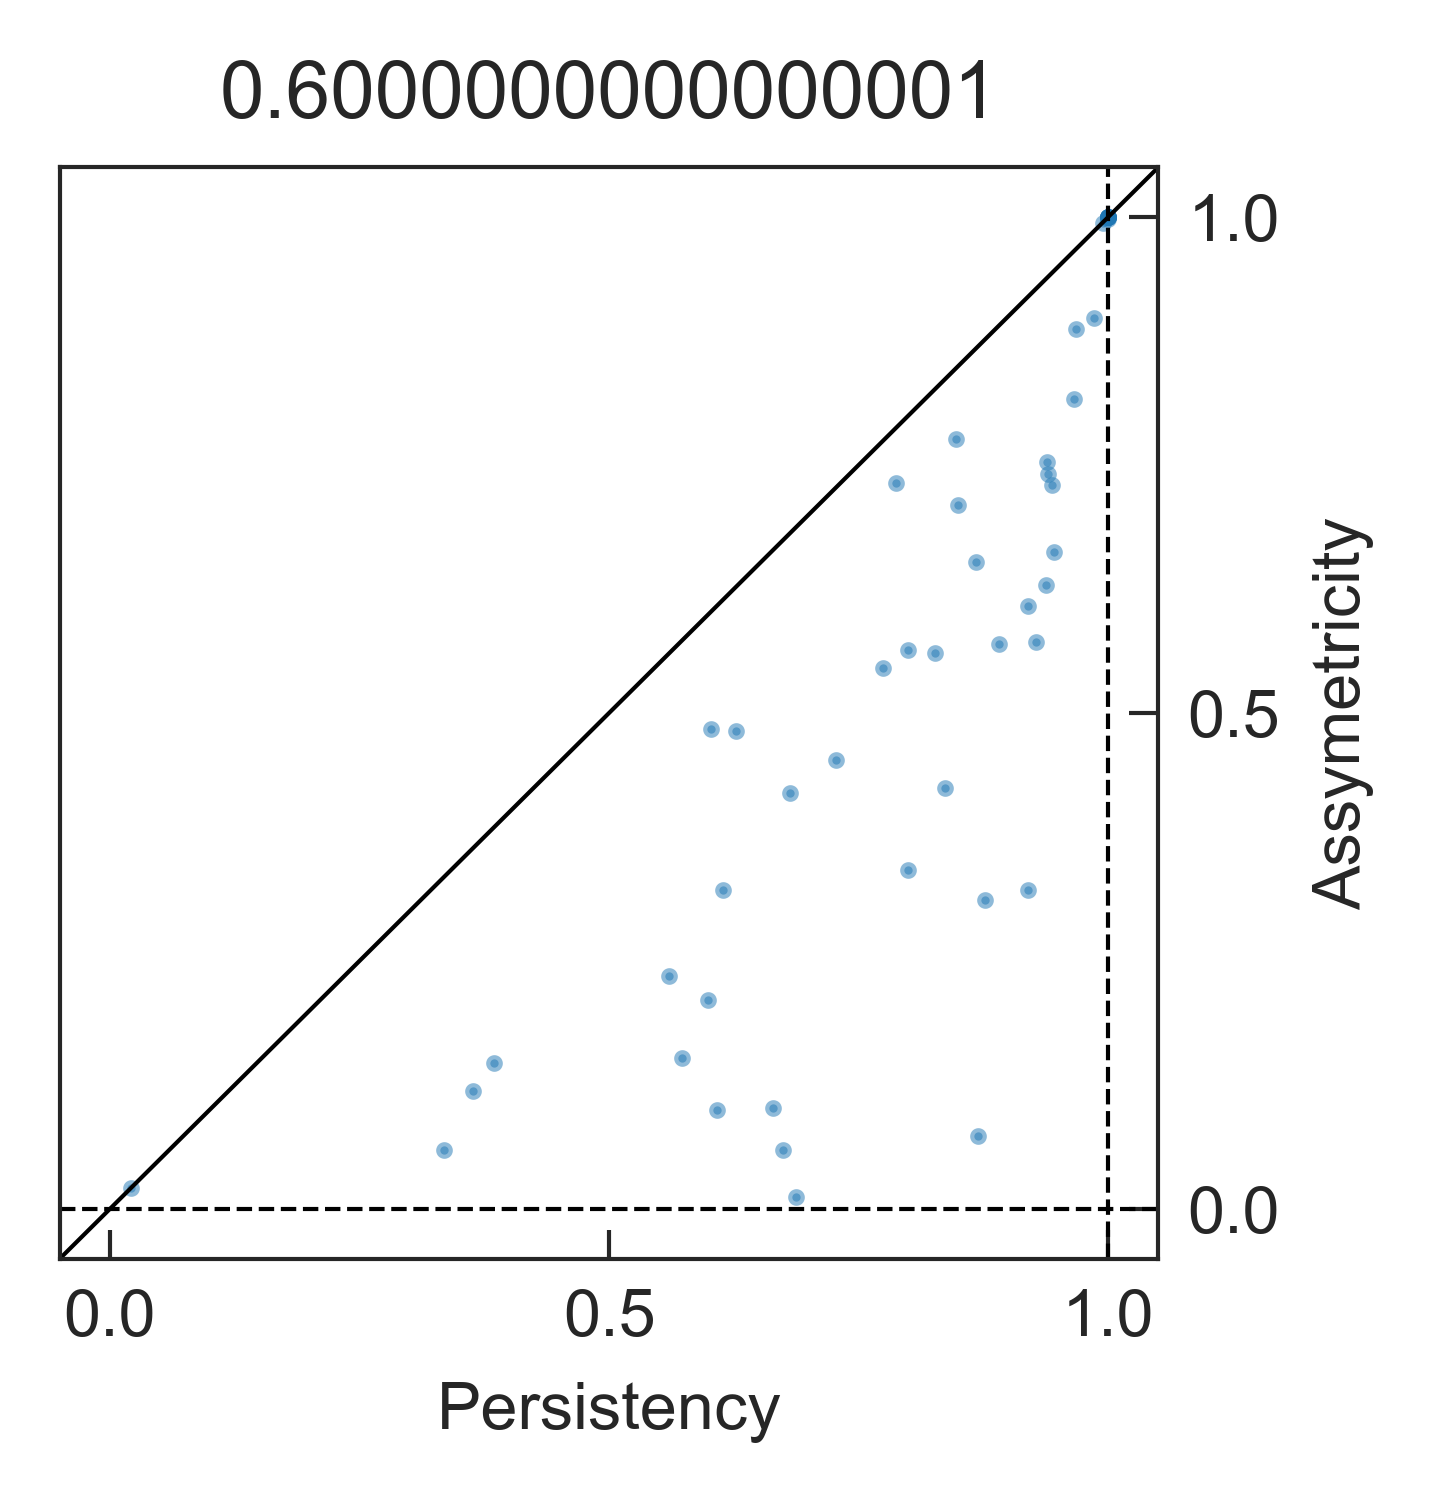

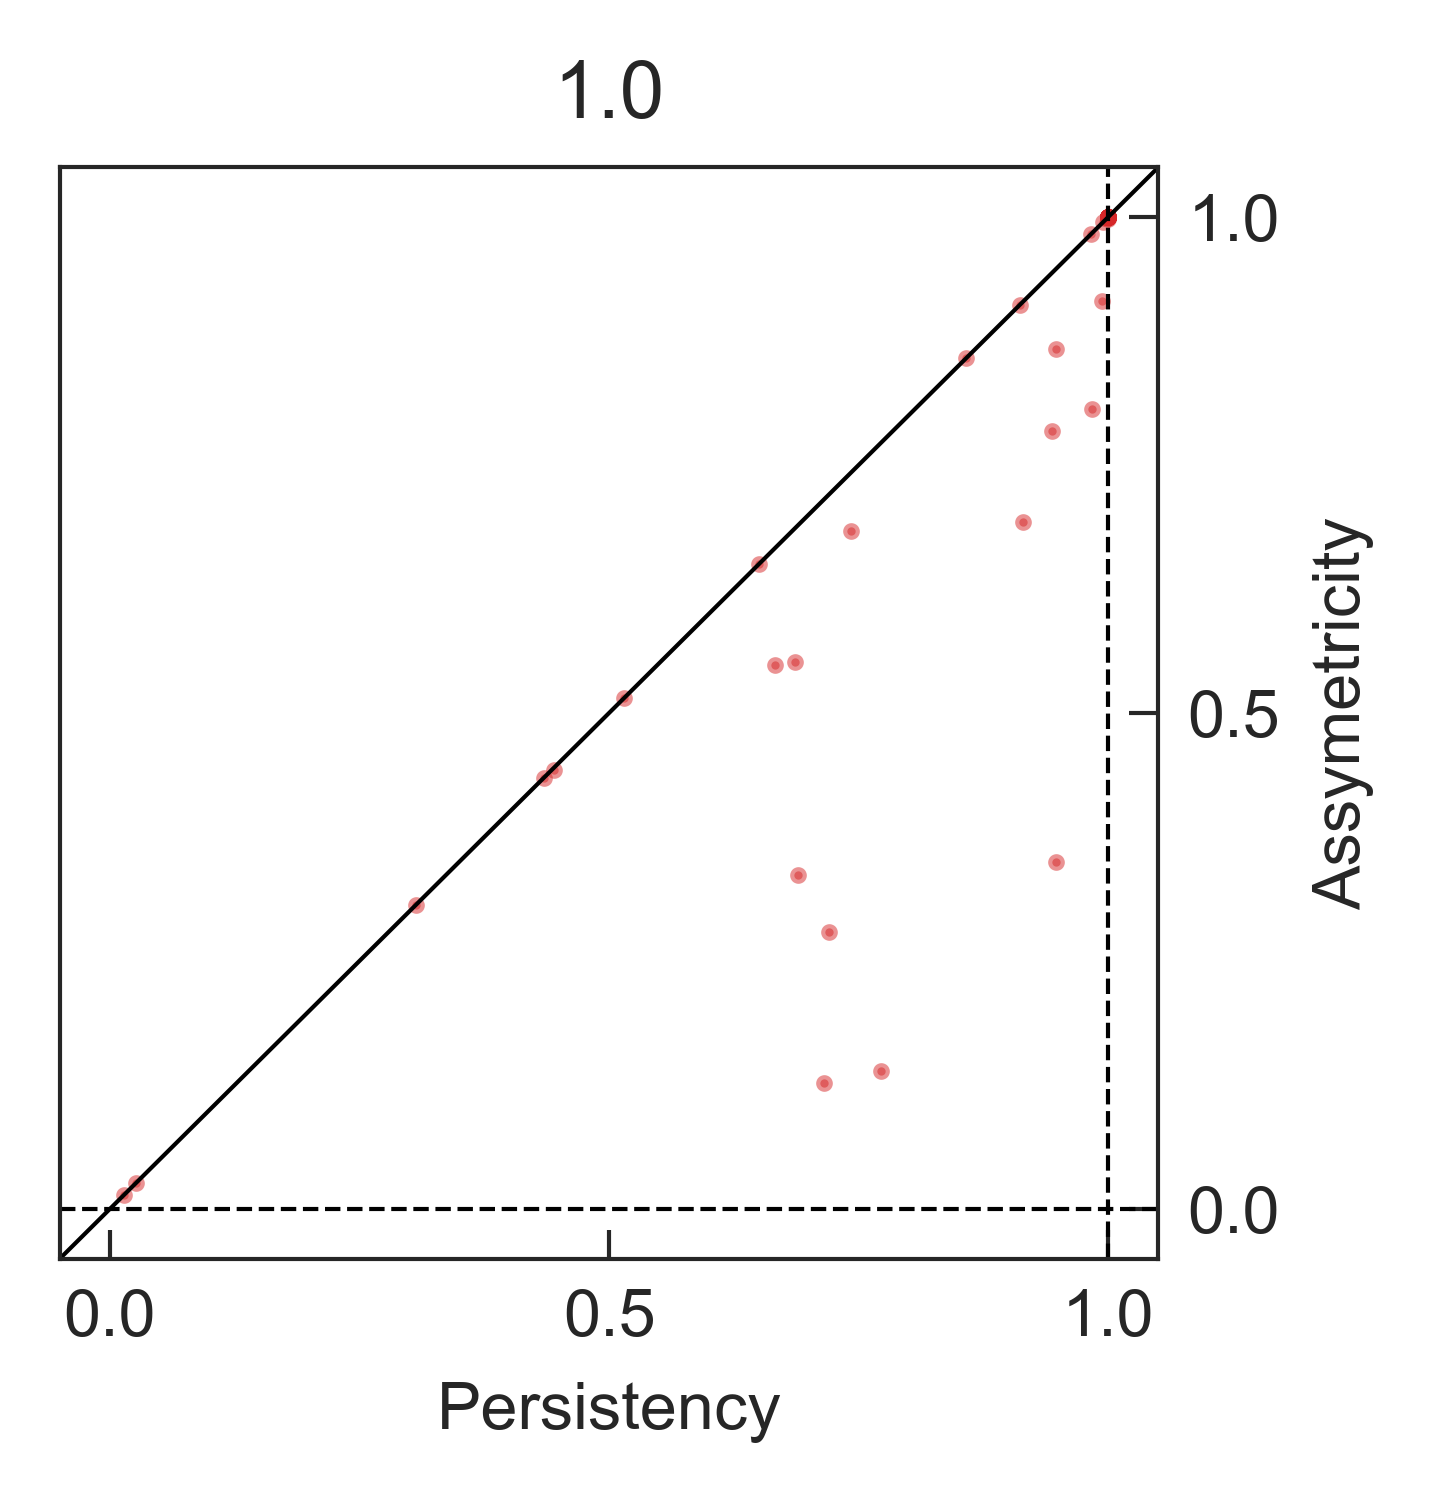

In [ ]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(43)
N=50
for c_i,i in enumerate([3, 6, 10]):

    Null_model_rep=5



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        data1=df1[i,:N]
        data2=df2[i,:N]


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        
        x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
        y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
        #print(type_name,np.mean(x*y), np.std(x*y))
        z=x*y
        #print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

        scatter(x,x*y,s=1,color=colors[c_i],alpha=0.5)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, color='k', linestyle='--', linewidth=.5)
        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        plt.xlabel('Persistency')
        plt.ylabel('Assymetricity')
        plt.title(f'{u_list[i]}')
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{u_list[i]}_style1.svg',bbox_inches='tight')






        

In [ ]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(43)
N=50
for c_i,i in enumerate(range(12)):

    Null_model_rep=5



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        data1=df1[i,:N]
        data2=df2[i,:N]


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        
        x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
        y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
        #print(type_name,np.mean(x*y), np.std(x*y))
        z=x*y
        #print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

        scatter(x,x*y,s=1,color=colors[c_i],alpha=0.5)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, color='k', linestyle='--', linewidth=.5)
        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        plt.xlabel('Persistency')
        plt.ylabel('Assymetricity')
        plt.title(f'{u_list[i]}')
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{u_list[i]}_style1.svg',bbox_inches='tight')






        

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


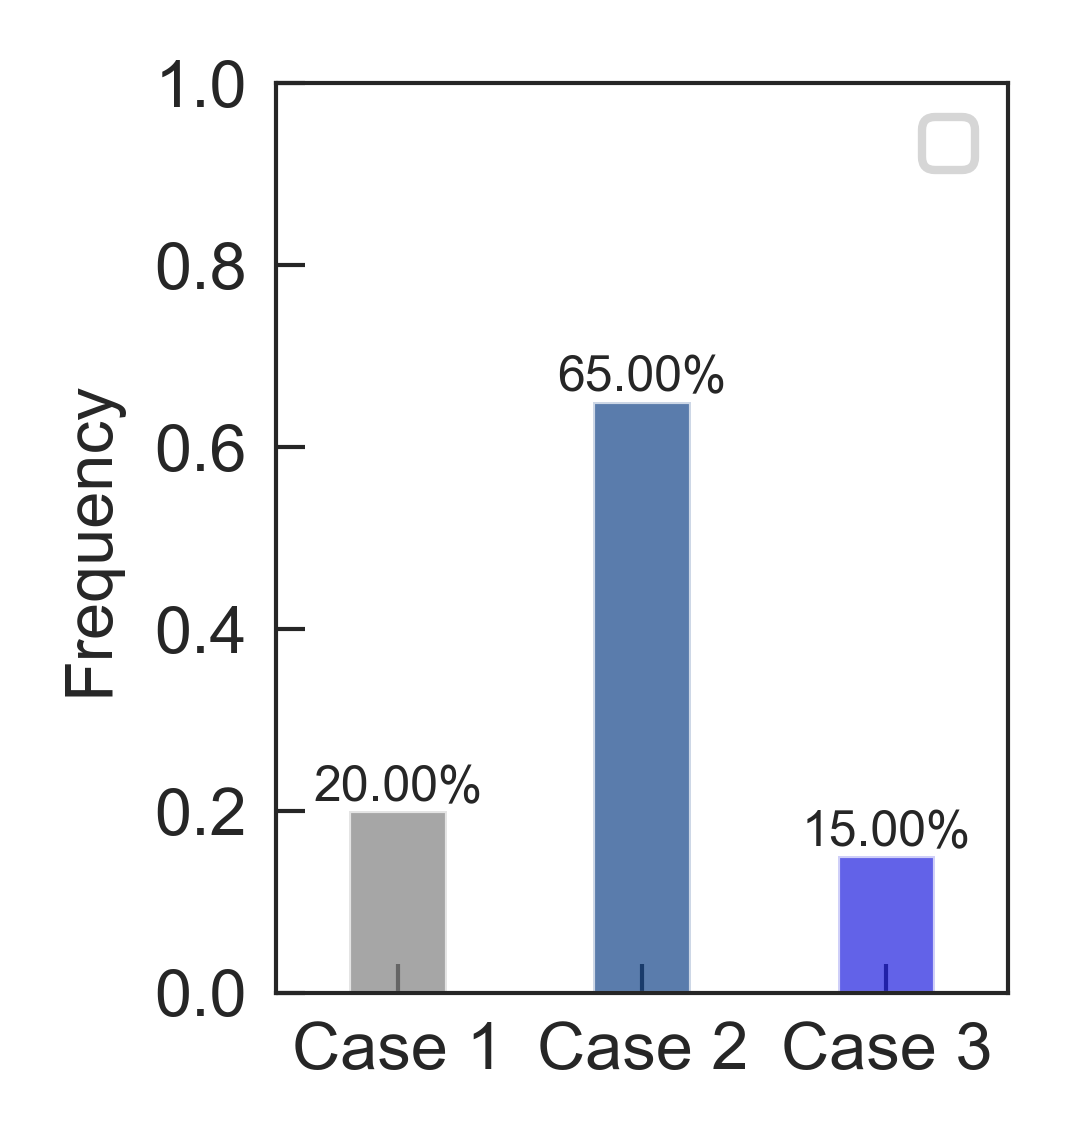

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/110982763.py:6: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


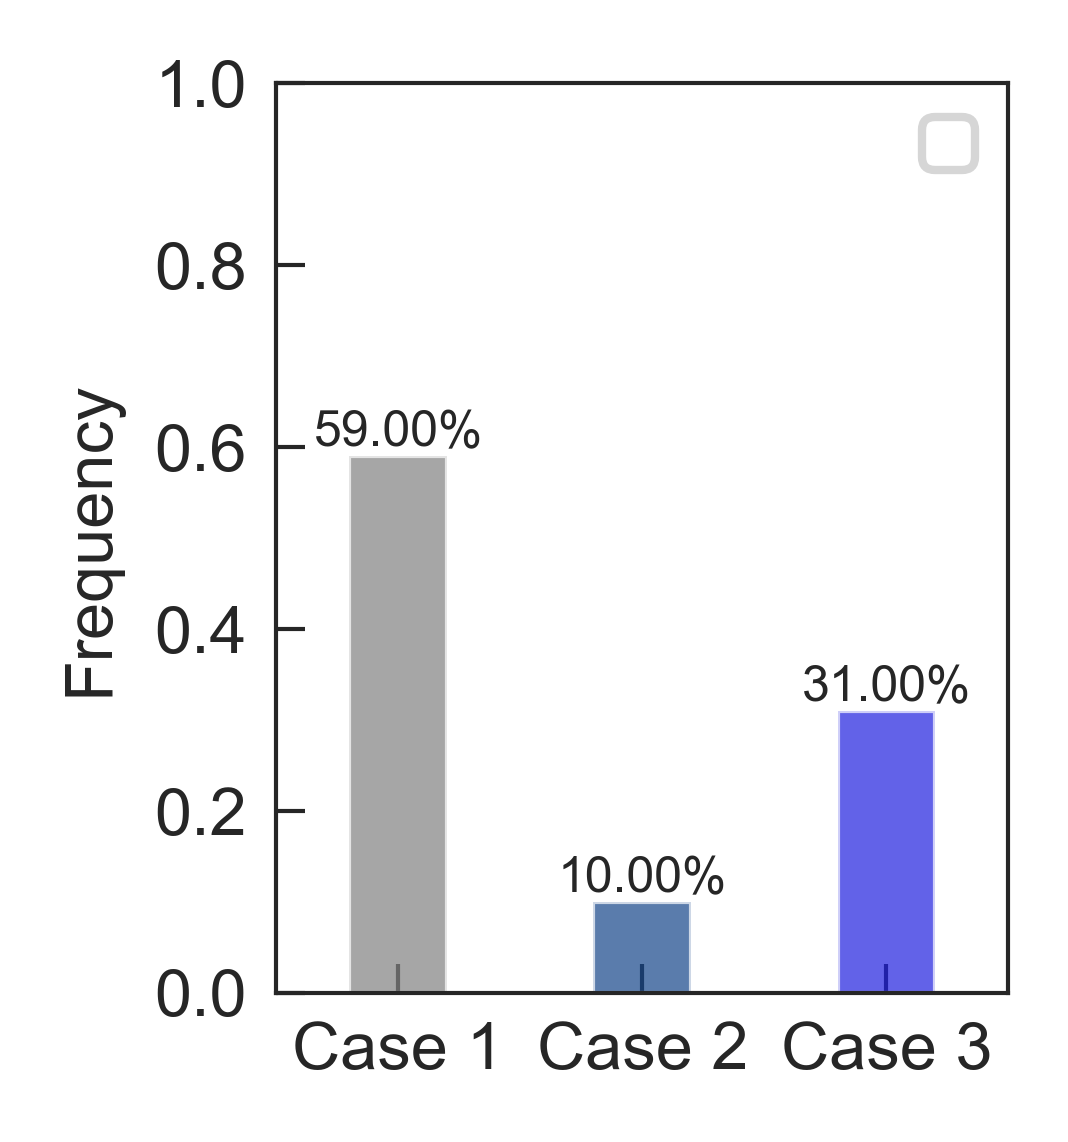

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/110982763.py:6: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/110982763.py:6: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


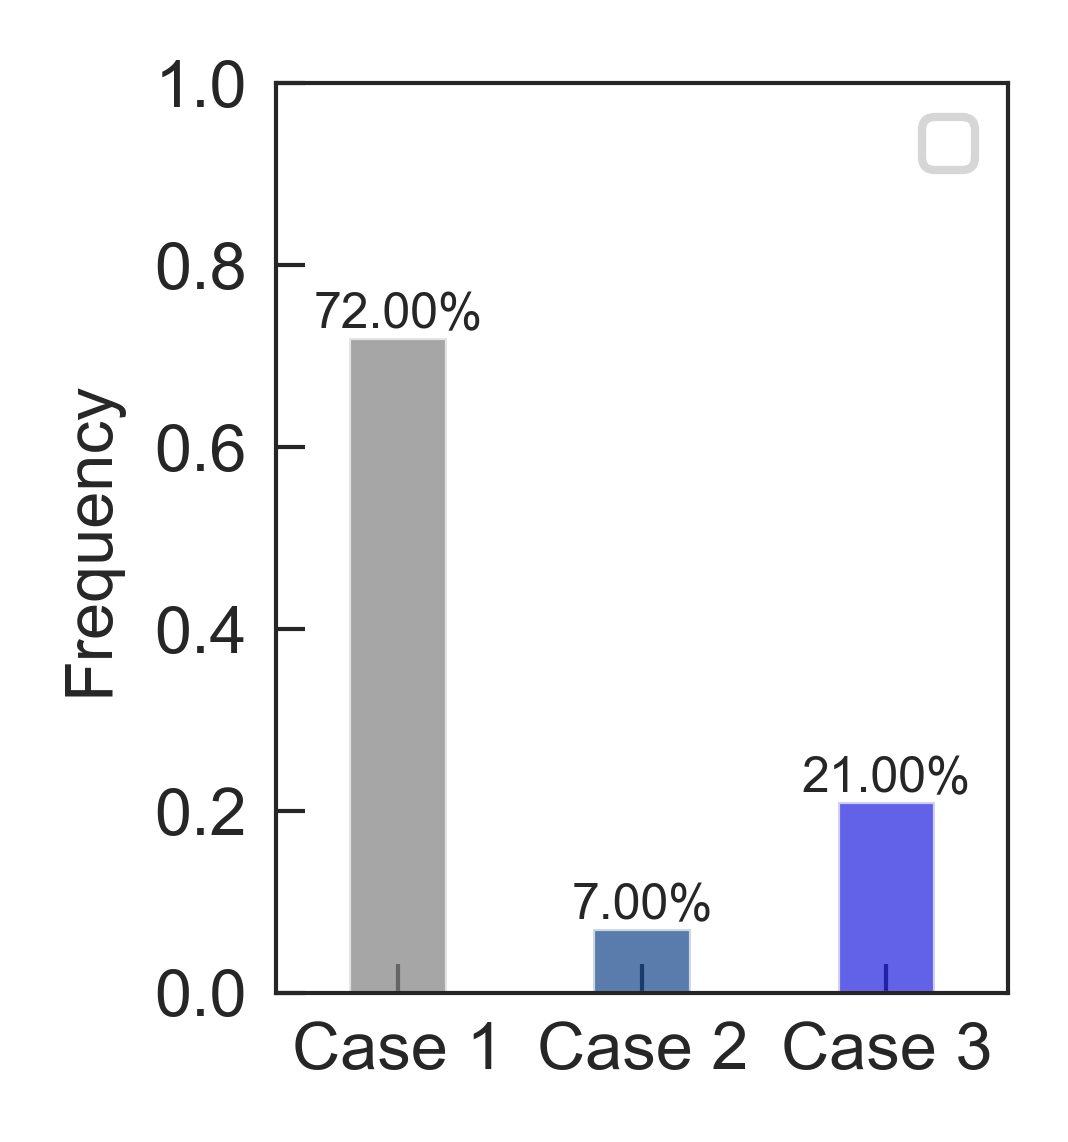

In [ ]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(43)
N=50
for c_i,i in enumerate(range(11)):

    Null_model_rep=5



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        data1=df1[i,:N]
        data2=df2[i,:N]


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        scatter(data1,data2,s=1,color=colors[c_i],alpha=0.5)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.2)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('to C1')
        plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{u_list[i]}_style1.svg',bbox_inches='tight')





        

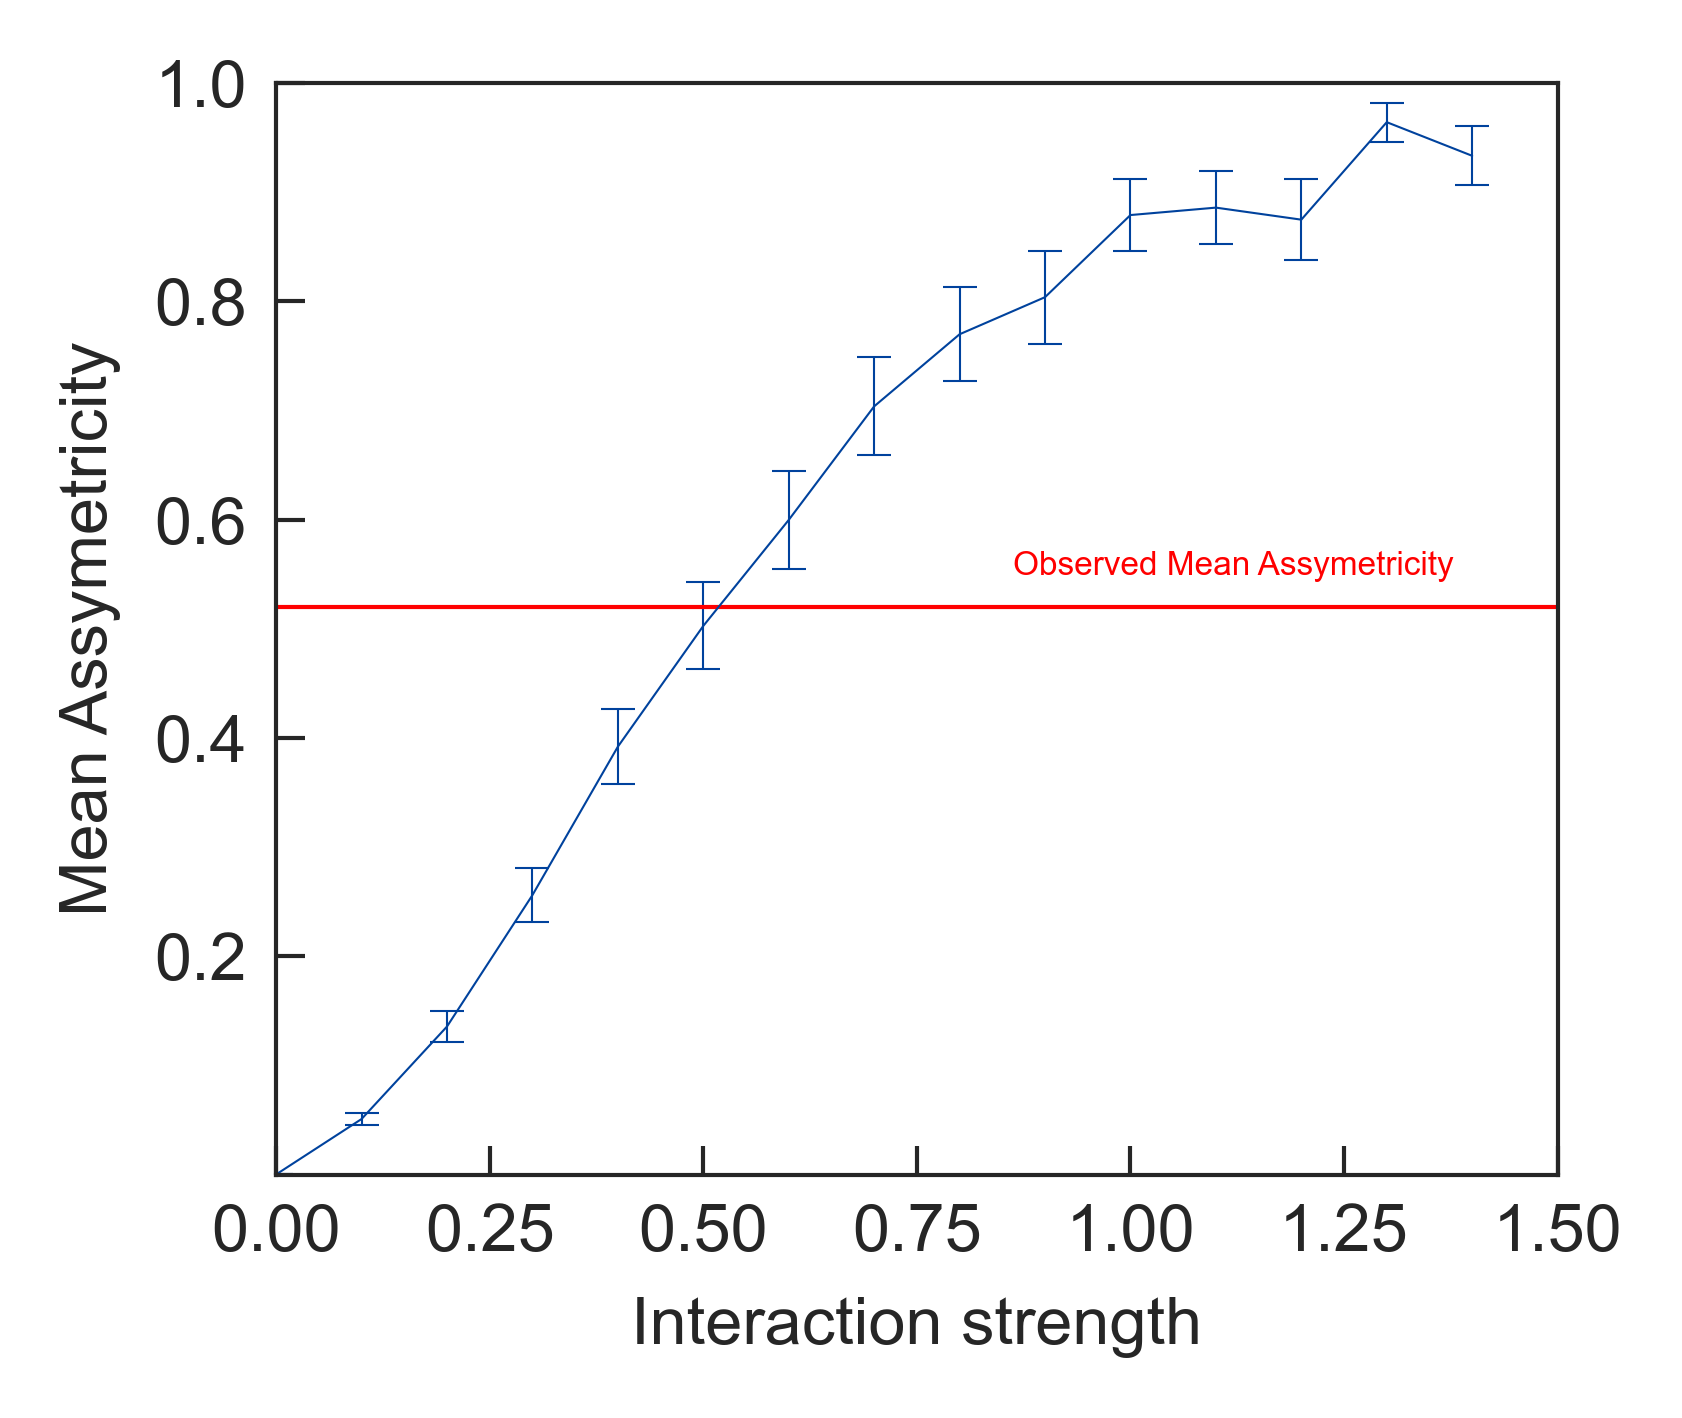

In [ ]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx')

df = df.values[0:,1:]


f, ax = plt.subplots(1, figsize=(70*mm,60*mm), facecolor='w', edgecolor='k')

x=u_list
y=np.mean(df,1)
yerr=np.std(df,1)/np.sqrt(df.shape[1])
plt.errorbar(x,y,yerr, linewidth=0.25, color=my_cmap(0), elinewidth=.25, capsize=2,capthick=.25)
#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)

Obs=0.52
plt.axhline(y=Obs, color='red', linewidth=0.5)

# Add text "Observed" above the line
plt.text(1.12, Obs+0.03, "Observed Mean Assymetricity", color='red', fontsize=4, ha='center')
plt.xlabel('Interaction strength')
plt.ylabel('Mean Assymetricity')
plt.ylim(3*1e-4, 1)
plt.xlim(0, 1.5)

# Show the plot
plt.show()
# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_errorbar.svg', bbox_inches='tight')


In [ ]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

In [ ]:

data={}
for i in range(size(df1,0)):
    data_i=[]
    for j in range(size(df1,1)):
        x,y=calculate_assymetricity(df1[i,j],df2[i,j],df3[i,j])
        ii=characterize_case(x,y)
        if ii==0:
            data_i.append(y)
        if ii==1:
            continue
        if ii==2:
            continue
    data[i]=data_i
    

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


In [ ]:
y

array([0.        , 0.        , 0.57714601, 0.6304049 , 0.71021113,
       0.7746769 , 0.83602181, 0.91459715, 0.92104718, 0.94240627,
       0.95963797, 0.96918621])

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


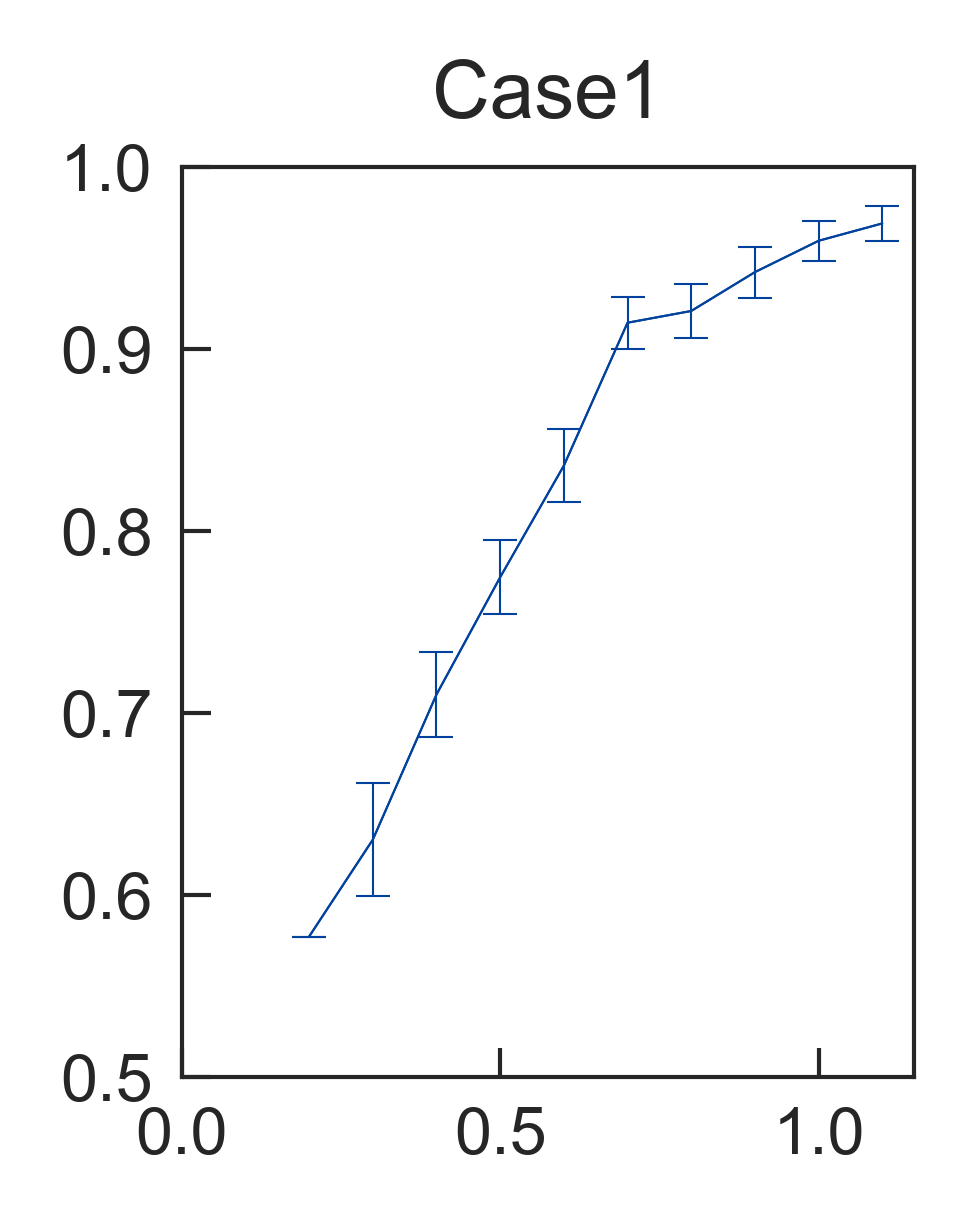

In [ ]:

data={}
data2={}
for i in range(size(df1,0)):
    data_i=[]
    data_j=[]
    for j in range(size(df1,1)):
        x,y=calculate_assymetricity(df1[i,j],df2[i,j],df3[i,j])
        ii=characterize_case(x,y)
        if ii==0:
            data_i.append(y)
            data_j.append(x)
        if ii==1:
            continue
        if ii==2:
            continue
    data[i]=data_i
    data2[i]=data_j
    
    
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=2

x=u_list
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(size(df1,0)):
    if len(data[i])==0:
        continue
    #plt.scatter([u_list[i]]*len(data[i]), data[i], s=0.5, color= my_cmap(0))
plt.plot(x[fromN:], y[fromN:], linewidth=0.25, color=my_cmap(0))
plt.errorbar(x[fromN:],y[fromN:],yerr[fromN:], linewidth=0.25, color=my_cmap(0), elinewidth=.25, capsize=2,capthick=.25)



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('y')
plt.xlim(0, 1.15)
plt.ylim(0.5, 1)
plt.title('Case1')

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_y.svg', bbox_inches='tight')


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


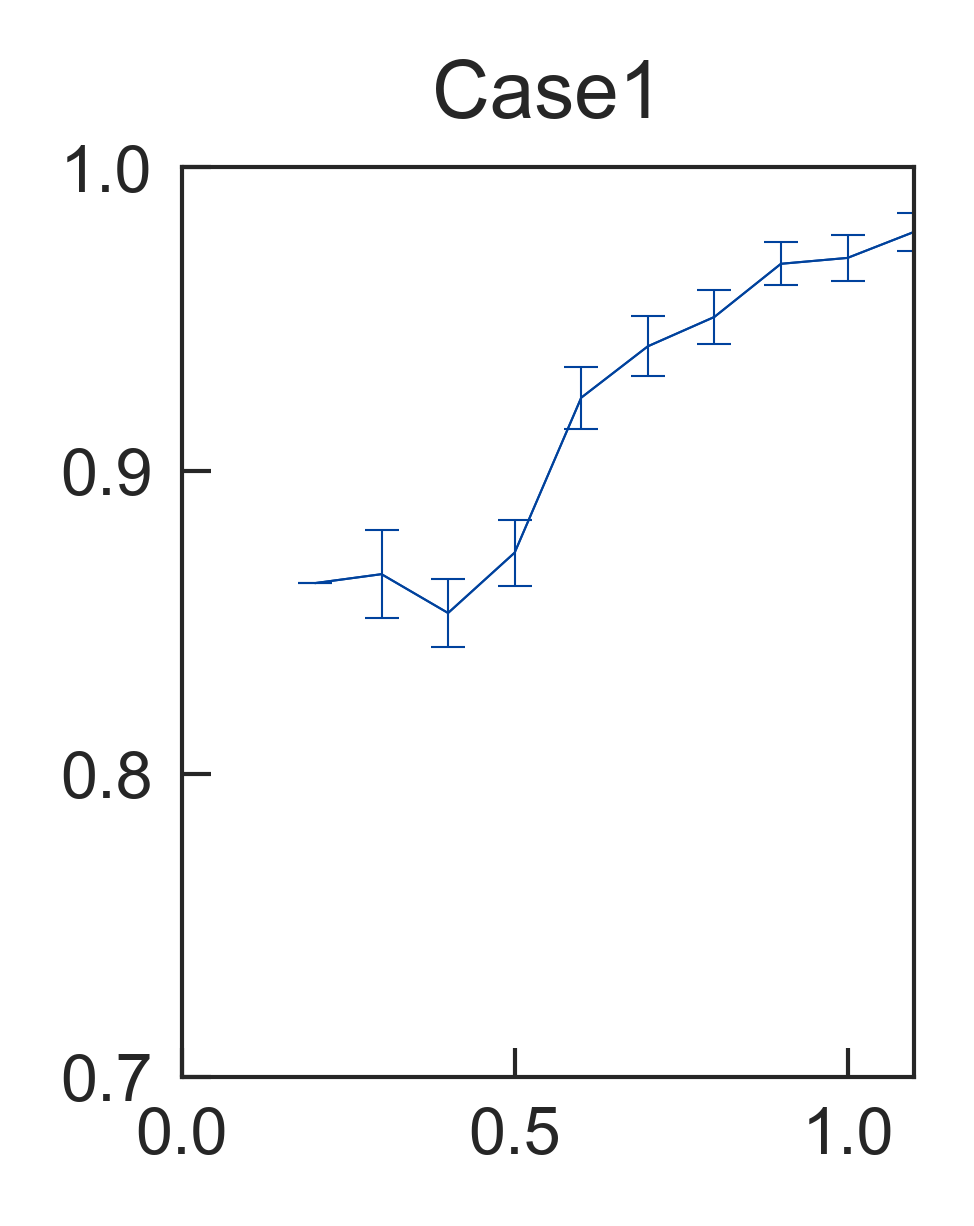

In [ ]:
data={}
data2={}
for i in range(size(df1,0)):
    data_i=[]
    data_j=[]
    for j in range(size(df1,1)):
        x,y=calculate_assymetricity(df1[i,j],df2[i,j],df3[i,j])
        ii=characterize_case(x,y)
        if ii==0:
            data_i.append(y)
            data_j.append(x)
        if ii==1:
            continue
        if ii==2:
            continue
    data[i]=data_i
    data2[i]=data_j
    
data=data2
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=2

x=u_list
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(size(df1,0)):
    if len(data[i])==0:
        continue
    #plt.scatter([u_list[i]]*len(data[i]), data[i], s=0.5, color= my_cmap(0))
plt.plot(x[fromN:], y[fromN:], linewidth=0.25, color=my_cmap(0))
plt.errorbar(x[fromN:],y[fromN:],yerr[fromN:], linewidth=0.25, color=my_cmap(0), elinewidth=.25, capsize=2,capthick=.25)


# Create a grey gap in the x-axis using a rectangle



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('x')
plt.xlim(0, 1.1)
plt.ylim(0.7, 1)
plt.title('Case1')


# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_x.svg', bbox_inches='tight')


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_69261/3697704590.py:3: RuntimeWarning: invalid value encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


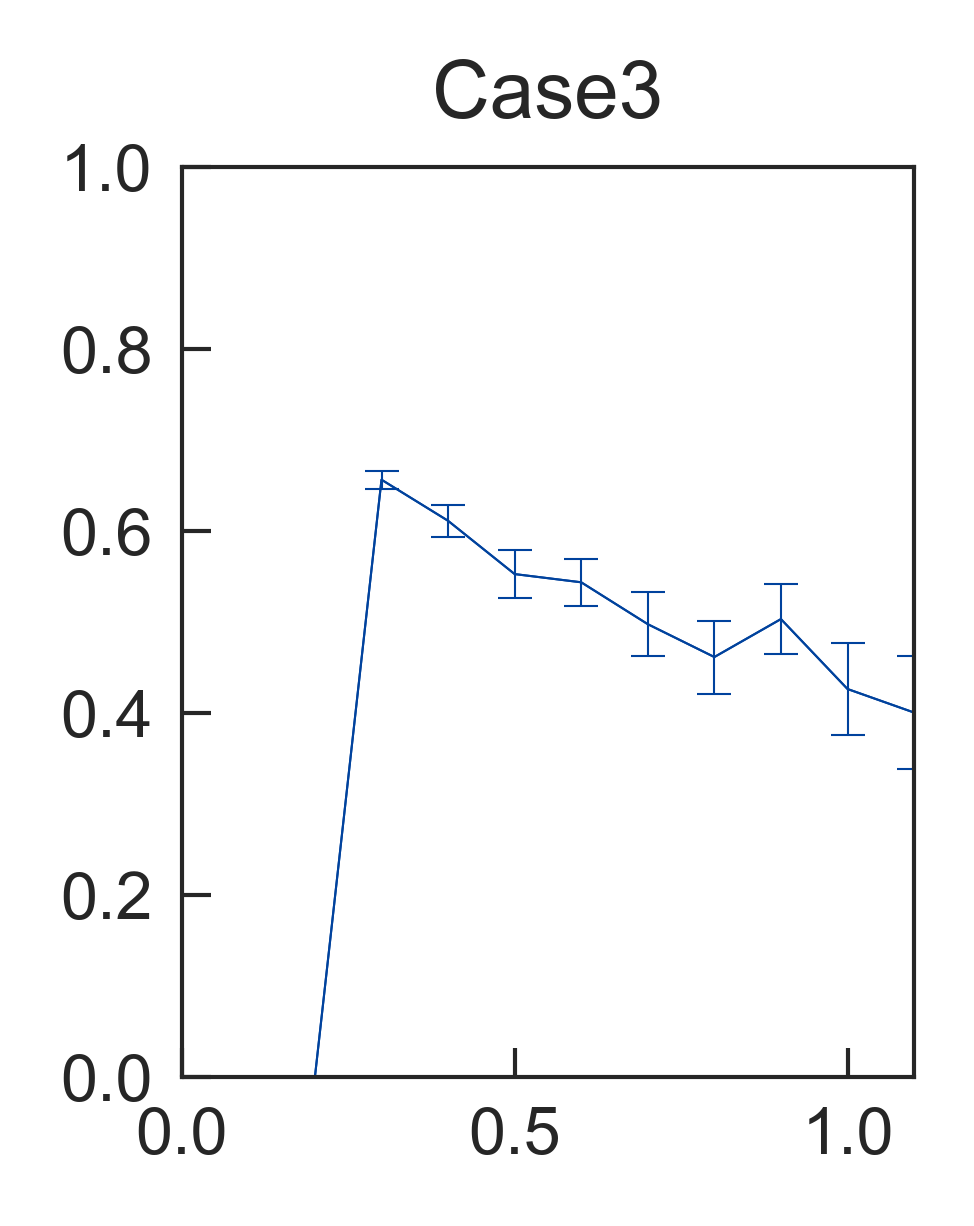

In [ ]:

data={}
data2={}
for i in range(size(df1,0)):
    data_i=[]
    data_j=[]
    for j in range(size(df1,1)):
        x,y=calculate_assymetricity(df1[i,j],df2[i,j],df3[i,j])
        ii=characterize_case(x,y)
        if ii==0:
            continue
        if ii==1:
            continue
        if ii==2:
            data_i.append(y)
            data_j.append(x)
    data[i]=data_i
    data2[i]=data_j
    
data=data2
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=2

x=u_list
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(size(df1,0)):
    if len(data[i])==0:
        continue
    #plt.scatter([u_list[i]]*len(data[i]), data[i], s=0.5, color= my_cmap(0))
plt.plot(x[fromN:], y[fromN:], linewidth=0.25, color=my_cmap(0))
plt.errorbar(x[fromN:],y[fromN:],yerr[fromN:], linewidth=0.25, color=my_cmap(0), elinewidth=.25, capsize=2,capthick=.25)



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('x')
plt.xlim(0, 1.1)
plt.ylim(0, 1)
plt.title('Case3')


# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_case3_x.svg', bbox_inches='tight')


In [ ]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet1')
df = df.values[0:,1:]
df1 = np.transpose(df)

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet2')
df = df.values[0:,1:]
df2 = np.transpose(df)